In [1]:
# SGD Naive one value based

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander

# Function to approximate
def f(x, y, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2))

# Settings
N, M = 64, 64               # number of Chebyshev nodes in each direction
d_x, d_y = 63, 63           # polynomial degree
R = 10                    # CP rank
n_iter = 1000             # total SGD iterations
lr = 1e-2                 # learning rate
epsilon = 1e-8            # small value to avoid div by zero

# Chebyshev nodes
x_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
y_nodes = np.cos(np.pi * np.arange(M) / (M - 1))
X, Y = np.meshgrid(x_nodes, y_nodes, indexing='ij')
F = f(X, Y)

# Chebyshev basis evaluations
Tx = chebvander(x_nodes, d_x)   # shape (N, d_x+1)
Ty = chebvander(y_nodes, d_y)   # shape (M, d_y+1)

# Initialize parameters
A_coeffs = np.random.randn(d_x + 1, R)
B_coeffs = np.random.randn(d_y + 1, R)
lambdas = np.ones(R)

# SGD loop
for it in range(n_iter):
    # Pick a random (i, j)
    i = np.random.randint(N)
    j = np.random.randint(M)

    Tx_i = Tx[i]  # shape (d_x+1,)
    Ty_j = Ty[j]  # shape (d_y+1,)

    # Compute current approximation at (i, j)
    approx = sum(
        lambdas[r] * (Tx_i @ A_coeffs[:, r]) * (Ty_j @ B_coeffs[:, r])
        for r in range(R)
    )
    target = F[i, j]
    err = approx - target

    # Update each component via SGD
    for r in range(R):
        a_r = Tx_i @ A_coeffs[:, r]
        b_r = Ty_j @ B_coeffs[:, r]

        grad_A = err * lambdas[r] * b_r * Tx_i
        grad_B = err * lambdas[r] * a_r * Ty_j
        grad_lambda = err * a_r * b_r

        A_coeffs[:, r] -= lr * grad_A
        B_coeffs[:, r] -= lr * grad_B
        lambdas[r] -= lr * grad_lambda

    # Clipping to prevent explosion
    lambdas = np.clip(lambdas, 1e-3, 1e3)

    # Monitoring RMSE every few iterations
    if it % 500 == 0:
        A_eval = Tx @ A_coeffs
        B_eval = Ty @ B_coeffs
        F_hat = sum(lambdas[r] * np.outer(A_eval[:, r], B_eval[:, r]) for r in range(R))
        rmse = np.sqrt(np.mean((F - F_hat)**2))
        print(f"Iter {it}, RMSE: {rmse:.2e}")


Iter 0, RMSE: 1.10e+03
Iter 500, RMSE: nan


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_59035/3115346335.py:69: RuntimeWarning: divide by zero encountered in matmul
  A_eval = Tx @ A_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_59035/3115346335.py:69: RuntimeWarning: overflow encountered in matmul
  A_eval = Tx @ A_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_59035/3115346335.py:69: RuntimeWarning: invalid value encountered in matmul
  A_eval = Tx @ A_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_59035/3115346335.py:70: RuntimeWarning: divide by zero encountered in matmul
  B_eval = Ty @ B_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_59035/3115346335.py:70: RuntimeWarning: overflow encountered in matmul
  B_eval = Ty @ B_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_59035/3115346335.py:70: RuntimeWarning: invalid value encountered in matmul
  B_eval = Ty @ B_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T

<>:80: SyntaxWarning: invalid escape sequence '\h'
<>:83: SyntaxWarning: invalid escape sequence '\h'
<>:80: SyntaxWarning: invalid escape sequence '\h'
<>:83: SyntaxWarning: invalid escape sequence '\h'
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2277156626.py:80: SyntaxWarning: invalid escape sequence '\h'
  ax2.set_title('Approximated Function $\hat{f}(x, y)$')
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2277156626.py:83: SyntaxWarning: invalid escape sequence '\h'
  ax2.set_zlabel('$\hat{f}(x, y)$')
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2277156626.py:43: RuntimeWarning: divide by zero encountered in matmul
  A_eval = Tx @ A       # (N, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2277156626.py:43: RuntimeWarning: overflow encountered in matmul
  A_eval = Tx @ A       # (N, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2277156626.py:43: RuntimeWarning: invalid value enco

Final RMSE: 1.14e-01


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2277156626.py:61: RuntimeWarning: divide by zero encountered in matmul
  A_eval = Tx @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2277156626.py:61: RuntimeWarning: overflow encountered in matmul
  A_eval = Tx @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2277156626.py:61: RuntimeWarning: invalid value encountered in matmul
  A_eval = Tx @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2277156626.py:62: RuntimeWarning: divide by zero encountered in matmul
  B_eval = Ty @ B_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2277156626.py:62: RuntimeWarning: overflow encountered in matmul
  B_eval = Ty @ B_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2277156626.py:62: RuntimeWarning: invalid value encountered in matmul
  B_eval = Ty @ B_opt


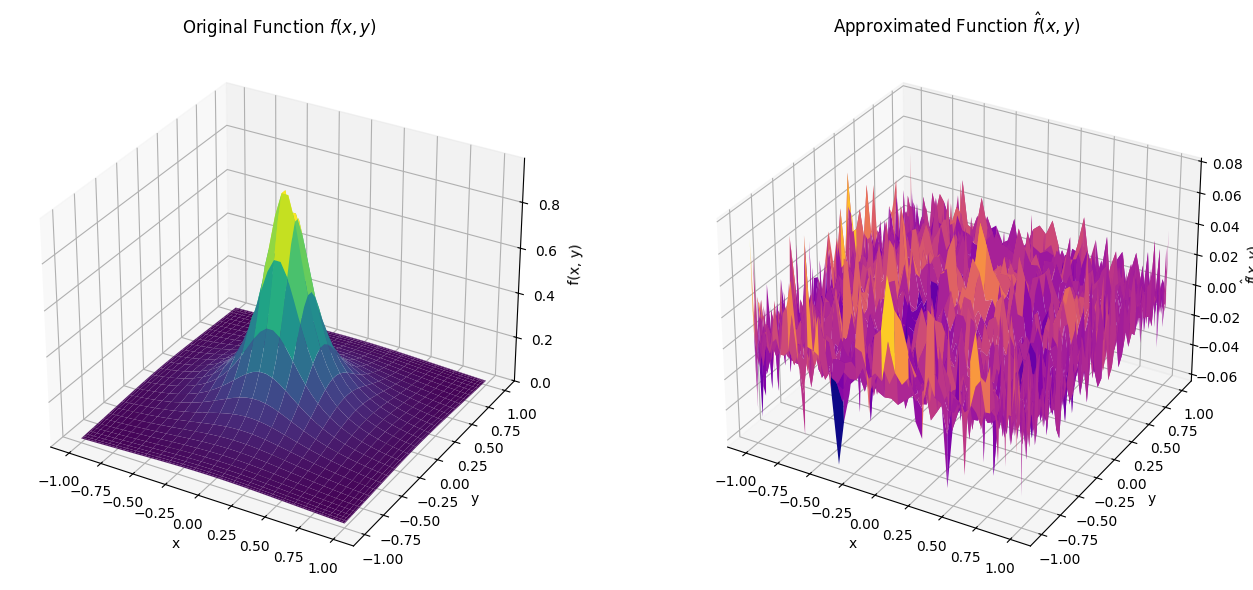

RMSE on [-1, 1]^2 uniform grid: 1.71e-01
L2 norm of reconstruction error: 7.29e+00


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2277156626.py:98: RuntimeWarning: divide by zero encountered in matmul
  A_eval_lin = Tx_lin @ A_opt     # (100, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2277156626.py:98: RuntimeWarning: overflow encountered in matmul
  A_eval_lin = Tx_lin @ A_opt     # (100, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2277156626.py:98: RuntimeWarning: invalid value encountered in matmul
  A_eval_lin = Tx_lin @ A_opt     # (100, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2277156626.py:99: RuntimeWarning: divide by zero encountered in matmul
  B_eval_lin = Ty_lin @ B_opt     # (100, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2277156626.py:99: RuntimeWarning: overflow encountered in matmul
  B_eval_lin = Ty_lin @ B_opt     # (100, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2277156626.py:99: RuntimeWarning: invalid v

In [2]:
# L-BFGS-B optimization (with lambda)

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander
from scipy.optimize import minimize
from mpl_toolkits.mplot3d import Axes3D

# Function to approximate
def f(x, y, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2))

# Settings
N, M = 64, 64
d_x, d_y = 63, 63
R = 10

# Chebyshev nodes
x_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
y_nodes = np.cos(np.pi * np.arange(M) / (M - 1))
X, Y = np.meshgrid(x_nodes, y_nodes, indexing='ij')
F = f(X, Y)

# Basis matrices
Tx = chebvander(x_nodes, d_x)   # (N, d_x+1)
Ty = chebvander(y_nodes, d_y)   # (M, d_y+1)

# Vectorize inputs for optimization
def pack_params(A, B, lambdas):
    return np.concatenate([A.ravel(), B.ravel(), lambdas])

def unpack_params(params):
    A_size = (d_x + 1) * R
    B_size = (d_y + 1) * R
    A = params[:A_size].reshape((d_x + 1, R))
    B = params[A_size:A_size + B_size].reshape((d_y + 1, R))
    lambdas = params[-R:]
    return A, B, lambdas

# Full objective function (RMSE)
def loss(params):
    A, B, lambdas = unpack_params(params)
    A_eval = Tx @ A       # (N, R)
    B_eval = Ty @ B       # (M, R)
    F_hat = sum(lambdas[r] * np.outer(A_eval[:, r], B_eval[:, r]) for r in range(R))
    return np.mean((F - F_hat)**2)

# Initialize parameters
A_init = np.random.randn(d_x + 1, R)
B_init = np.random.randn(d_y + 1, R)
lambdas_init = np.ones(R)
params_init = pack_params(A_init, B_init, lambdas_init)

# Optimization using L-BFGS-B
result = minimize(loss, params_init, method='L-BFGS-B', options={'maxiter': 10000, 'disp': True})

# Unpack final result
A_opt, B_opt, lambdas_opt = unpack_params(result.x)

# Final evaluation
A_eval = Tx @ A_opt
B_eval = Ty @ B_opt
F_hat = sum(lambdas_opt[r] * np.outer(A_eval[:, r], B_eval[:, r]) for r in range(R))
rmse = np.sqrt(np.mean((F - F_hat)**2))
print(f"Final RMSE: {rmse:.2e}")

fig = plt.figure(figsize=(14, 6))

# 3D plot of original function F
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X, Y, F, cmap='viridis', edgecolor='none')
ax1.set_title('Original Function $f(x, y)$')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x, y)')

# 3D plot of approximated function F_hat
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X, Y, F_hat, cmap='plasma', edgecolor='none')
ax2.set_title('Approximated Function $\hat{f}(x, y)$')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('$\hat{f}(x, y)$')

plt.tight_layout()
plt.show()

from numpy.polynomial.chebyshev import chebval2d

# --- RMSE on linspace grid ---
x_lin = np.linspace(-1, 1, 100)
y_lin = np.linspace(-1, 1, 100)
X_lin, Y_lin = np.meshgrid(x_lin, y_lin, indexing='ij')

# Evaluate Chebyshev polynomials at grid points
Tx_lin = chebvander(x_lin, d_x)
Ty_lin = chebvander(y_lin, d_y)
A_eval_lin = Tx_lin @ A_opt     # (100, R)
B_eval_lin = Ty_lin @ B_opt     # (100, R)

# Predict values
F_pred_grid = sum(lambdas_opt[r] * np.outer(A_eval_lin[:, r], B_eval_lin[:, r]) for r in range(R))
F_true_grid = f(X_lin, Y_lin)

rmse_grid = np.sqrt(np.mean((F_pred_grid - F_true_grid) ** 2))
print(f"RMSE on [-1, 1]^2 uniform grid: {rmse_grid:.2e}")

# --- L2 norm between original and reconstructed tensor ---
l2_error = np.linalg.norm(F - F_hat)
print(f"L2 norm of reconstruction error: {l2_error:.2e}")


<>:78: SyntaxWarning: invalid escape sequence '\h'
<>:81: SyntaxWarning: invalid escape sequence '\h'
<>:78: SyntaxWarning: invalid escape sequence '\h'
<>:81: SyntaxWarning: invalid escape sequence '\h'
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/1122244995.py:78: SyntaxWarning: invalid escape sequence '\h'
  ax2.set_title('Approximated Function $\hat{f}(x, y)$')
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/1122244995.py:81: SyntaxWarning: invalid escape sequence '\h'
  ax2.set_zlabel('$\hat{f}(x, y)$')
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/1122244995.py:42: RuntimeWarning: divide by zero encountered in matmul
  A_eval = Tx @ A       # (N, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/1122244995.py:42: RuntimeWarning: overflow encountered in matmul
  A_eval = Tx @ A       # (N, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/1122244995.py:42: RuntimeWarning: invalid value enco

Final RMSE: 2.99e-02


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/1122244995.py:58: RuntimeWarning: divide by zero encountered in matmul
  A_eval = Tx @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/1122244995.py:58: RuntimeWarning: overflow encountered in matmul
  A_eval = Tx @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/1122244995.py:58: RuntimeWarning: invalid value encountered in matmul
  A_eval = Tx @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/1122244995.py:59: RuntimeWarning: divide by zero encountered in matmul
  B_eval = Ty @ B_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/1122244995.py:59: RuntimeWarning: overflow encountered in matmul
  B_eval = Ty @ B_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/1122244995.py:59: RuntimeWarning: invalid value encountered in matmul
  B_eval = Ty @ B_opt


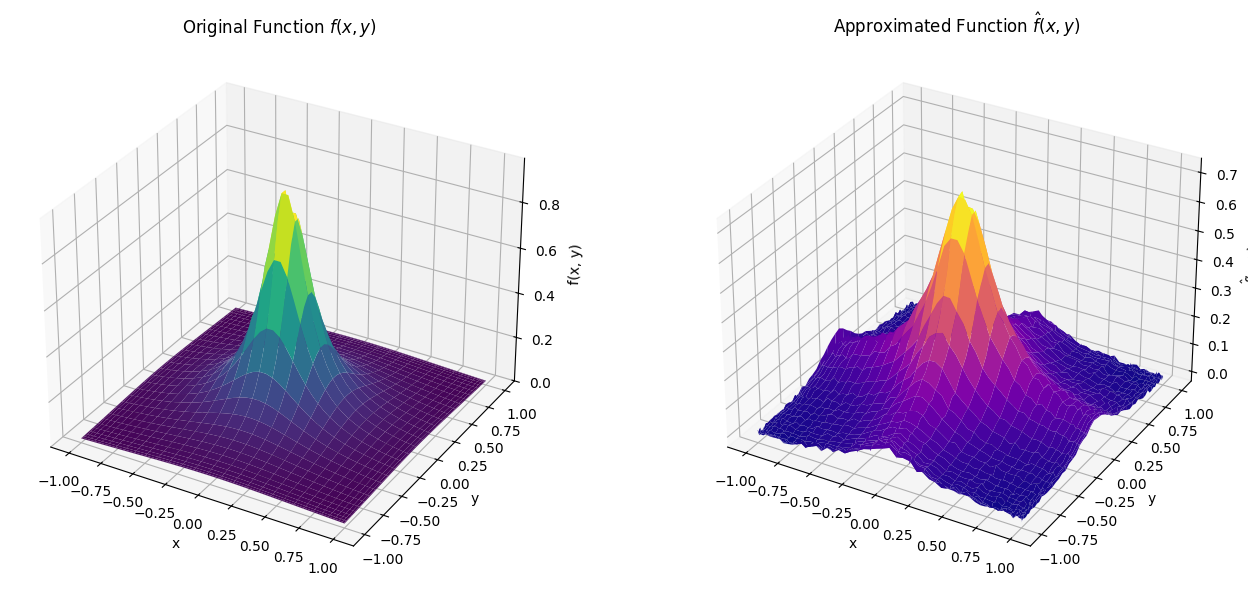

RMSE on [-1, 1]^2 uniform grid: 3.66e-02
L2 norm of reconstruction error: 1.91e+00


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/1122244995.py:94: RuntimeWarning: divide by zero encountered in matmul
  A_eval_lin = Tx_lin @ A_opt       # (100, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/1122244995.py:94: RuntimeWarning: overflow encountered in matmul
  A_eval_lin = Tx_lin @ A_opt       # (100, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/1122244995.py:94: RuntimeWarning: invalid value encountered in matmul
  A_eval_lin = Tx_lin @ A_opt       # (100, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/1122244995.py:95: RuntimeWarning: divide by zero encountered in matmul
  B_eval_lin = Ty_lin @ B_opt       # (100, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/1122244995.py:95: RuntimeWarning: overflow encountered in matmul
  B_eval_lin = Ty_lin @ B_opt       # (100, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/1122244995.py:95: RuntimeWarning:

In [4]:
# L-BFGS-B optimization (without lambda)

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander
from scipy.optimize import minimize
from mpl_toolkits.mplot3d import Axes3D

# Function to approximate
def f(x, y, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2))

# Settings
N, M = 64, 64
d_x, d_y = 63, 63
R = 10

# Chebyshev nodes
x_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
y_nodes = np.cos(np.pi * np.arange(M) / (M - 1))
X, Y = np.meshgrid(x_nodes, y_nodes, indexing='ij')
F = f(X, Y)

# Chebyshev basis evaluations
Tx = chebvander(x_nodes, d_x)   # (N, d_x+1)
Ty = chebvander(y_nodes, d_y)   # (M, d_y+1)

# Helper functions to pack/unpack parameters
def pack_params(A, B):
    return np.concatenate([A.ravel(), B.ravel()])

def unpack_params(params):
    A_size = (d_x + 1) * R
    B_size = (d_y + 1) * R
    A = params[:A_size].reshape((d_x + 1, R))
    B = params[A_size:].reshape((d_y + 1, R))
    return A, B

# Loss function (mean squared error)
def loss(params):
    A, B = unpack_params(params)
    A_eval = Tx @ A       # (N, R)
    B_eval = Ty @ B       # (M, R)
    F_hat = sum(np.outer(A_eval[:, r], B_eval[:, r]) for r in range(R))
    return np.mean((F - F_hat)**2)

# Initialize A and B
np.random.seed(0)
A_init = 0.01 * np.random.randn(d_x + 1, R)
B_init = 0.01 * np.random.randn(d_y + 1, R)
params_init = pack_params(A_init, B_init)

# Optimize using BFGS
result = minimize(loss, params_init, method='L-BFGS-B', options={'maxiter': 10000, 'disp': True})

# Unpack optimized parameters
A_opt, B_opt = unpack_params(result.x)
A_eval = Tx @ A_opt
B_eval = Ty @ B_opt
F_hat = sum(np.outer(A_eval[:, r], B_eval[:, r]) for r in range(R))
rmse = np.sqrt(np.mean((F - F_hat)**2))
print(f"Final RMSE: {rmse:.2e}")

# Plot original and approximated function in 3D
fig = plt.figure(figsize=(14, 6))

# Plot original function
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X, Y, F, cmap='viridis', edgecolor='none')
ax1.set_title('Original Function $f(x, y)$')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x, y)')

# Plot approximated function
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X, Y, F_hat, cmap='plasma', edgecolor='none')
ax2.set_title('Approximated Function $\hat{f}(x, y)$')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('$\hat{f}(x, y)$')

plt.tight_layout()
plt.show()

# --- RMSE on uniform [-1, 1]^2 grid ---
x_lin = np.linspace(-1, 1, 100)
y_lin = np.linspace(-1, 1, 100)
X_lin, Y_lin = np.meshgrid(x_lin, y_lin, indexing='ij')

# Evaluate Chebyshev basis at linspace grid
Tx_lin = chebvander(x_lin, d_x)   # (100, d_x+1)
Ty_lin = chebvander(y_lin, d_y)   # (100, d_y+1)
A_eval_lin = Tx_lin @ A_opt       # (100, R)
B_eval_lin = Ty_lin @ B_opt       # (100, R)

# Predict on uniform grid
F_pred_grid = sum(np.outer(A_eval_lin[:, r], B_eval_lin[:, r]) for r in range(R))
F_true_grid = f(X_lin, Y_lin)

# Compute RMSE on uniform grid
rmse_grid = np.sqrt(np.mean((F_pred_grid - F_true_grid) ** 2))
print(f"RMSE on [-1, 1]^2 uniform grid: {rmse_grid:.2e}")

# --- L2 norm on Chebyshev tensor ---
l2_error = np.linalg.norm(F - F_hat)
print(f"L2 norm of reconstruction error: {l2_error:.2e}")


<>:79: SyntaxWarning: invalid escape sequence '\h'
<>:82: SyntaxWarning: invalid escape sequence '\h'
<>:79: SyntaxWarning: invalid escape sequence '\h'
<>:82: SyntaxWarning: invalid escape sequence '\h'
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2707265743.py:79: SyntaxWarning: invalid escape sequence '\h'
  ax2.set_title('Approximated Function $\hat{f}(x, y)$')
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2707265743.py:82: SyntaxWarning: invalid escape sequence '\h'
  ax2.set_zlabel('$\hat{f}(x, y)$')
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2707265743.py:42: RuntimeWarning: divide by zero encountered in matmul
  A_eval = Tx @ A       # (N, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2707265743.py:42: RuntimeWarning: overflow encountered in matmul
  A_eval = Tx @ A       # (N, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2707265743.py:42: RuntimeWarning: invalid value enco

         Current function value: 0.000794
         Iterations: 163
         Function evaluations: 311143
         Gradient evaluations: 241
Final RMSE: 2.82e-02


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2707265743.py:42: RuntimeWarning: divide by zero encountered in matmul
  A_eval = Tx @ A       # (N, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2707265743.py:42: RuntimeWarning: overflow encountered in matmul
  A_eval = Tx @ A       # (N, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2707265743.py:42: RuntimeWarning: invalid value encountered in matmul
  A_eval = Tx @ A       # (N, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2707265743.py:43: RuntimeWarning: divide by zero encountered in matmul
  B_eval = Ty @ B       # (M, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2707265743.py:43: RuntimeWarning: overflow encountered in matmul
  B_eval = Ty @ B       # (M, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2707265743.py:43: RuntimeWarning: invalid value encountered in matmul
  B_eval = Ty @ B       # (M, R)


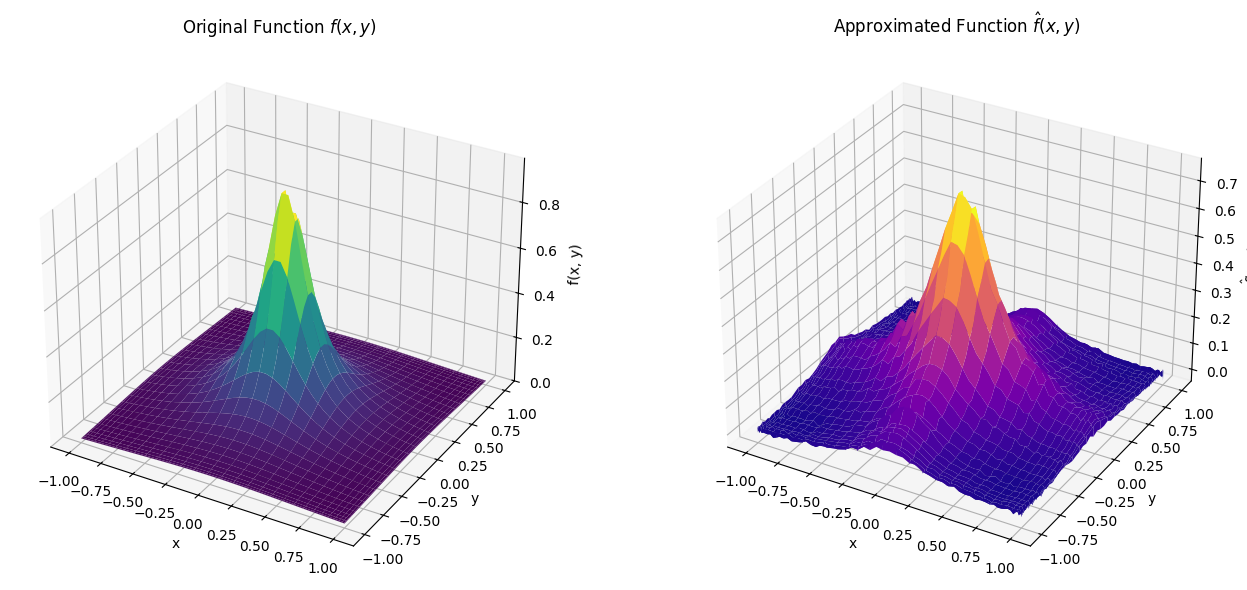

RMSE on [-1, 1]^2 uniform grid: 3.45e-02
L2 norm of reconstruction error: 1.80e+00


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2707265743.py:95: RuntimeWarning: divide by zero encountered in matmul
  A_eval_lin = Tx_lin @ A_opt         # (100, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2707265743.py:95: RuntimeWarning: overflow encountered in matmul
  A_eval_lin = Tx_lin @ A_opt         # (100, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2707265743.py:95: RuntimeWarning: invalid value encountered in matmul
  A_eval_lin = Tx_lin @ A_opt         # (100, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2707265743.py:96: RuntimeWarning: divide by zero encountered in matmul
  B_eval_lin = Ty_lin @ B_opt         # (100, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2707265743.py:96: RuntimeWarning: overflow encountered in matmul
  B_eval_lin = Ty_lin @ B_opt         # (100, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2707265743.py:96: Runti

In [6]:
# BFGS optimization (with lambda)

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander
from scipy.optimize import minimize

# Function to approximate
def f(x, y, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2))

# Settings
N, M = 64, 64
d_x, d_y = 63, 63
R = 10

# Chebyshev nodes
x_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
y_nodes = np.cos(np.pi * np.arange(M) / (M - 1))
X, Y = np.meshgrid(x_nodes, y_nodes, indexing='ij')
F = f(X, Y)

# Basis matrices
Tx = chebvander(x_nodes, d_x)   # (N, d_x+1)
Ty = chebvander(y_nodes, d_y)   # (M, d_y+1)

# Vectorize inputs for optimization
def pack_params(A, B, lambdas):
    return np.concatenate([A.ravel(), B.ravel(), lambdas])

def unpack_params(params):
    A_size = (d_x + 1) * R
    B_size = (d_y + 1) * R
    A = params[:A_size].reshape((d_x + 1, R))
    B = params[A_size:A_size + B_size].reshape((d_y + 1, R))
    lambdas = params[-R:]
    return A, B, lambdas

# Full objective function (RMSE)
def loss(params):
    A, B, lambdas = unpack_params(params)
    A_eval = Tx @ A       # (N, R)
    B_eval = Ty @ B       # (M, R)
    F_hat = sum(lambdas[r] * np.outer(A_eval[:, r], B_eval[:, r]) for r in range(R))
    return np.mean((F - F_hat)**2)

# Initialize parameters
A_init = np.random.randn(d_x + 1, R)
B_init = np.random.randn(d_y + 1, R)
lambdas_init = np.ones(R)
params_init = pack_params(A_init, B_init, lambdas_init)

# Optimization using L-BFGS-B
result = minimize(loss, params_init, method='BFGS', options={'maxiter': 10000, 'disp': True})

# Unpack final result
A_opt, B_opt, lambdas_opt = unpack_params(result.x)

# Final evaluation
A_eval = Tx @ A_opt
B_eval = Ty @ B_opt
F_hat = sum(lambdas_opt[r] * np.outer(A_eval[:, r], B_eval[:, r]) for r in range(R))
rmse = np.sqrt(np.mean((F - F_hat)**2))
print(f"Final RMSE: {rmse:.2e}")

fig = plt.figure(figsize=(14, 6))

# 3D plot of original function F
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X, Y, F, cmap='viridis', edgecolor='none')
ax1.set_title('Original Function $f(x, y)$')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x, y)')

# 3D plot of approximated function F_hat
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X, Y, F_hat, cmap='plasma', edgecolor='none')
ax2.set_title('Approximated Function $\hat{f}(x, y)$')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('$\hat{f}(x, y)$')

plt.tight_layout()
plt.show()

# --- RMSE on [-1, 1]^2 uniform grid ---
x_lin = np.linspace(-1, 1, 100)
y_lin = np.linspace(-1, 1, 100)
X_lin, Y_lin = np.meshgrid(x_lin, y_lin, indexing='ij')

# Chebyshev basis at uniform grid
Tx_lin = chebvander(x_lin, d_x)     # (100, d_x+1)
Ty_lin = chebvander(y_lin, d_y)     # (100, d_y+1)
A_eval_lin = Tx_lin @ A_opt         # (100, R)
B_eval_lin = Ty_lin @ B_opt         # (100, R)

# Prediction on grid
F_pred_grid = sum(lambdas_opt[r] * np.outer(A_eval_lin[:, r], B_eval_lin[:, r]) for r in range(R))
F_true_grid = f(X_lin, Y_lin)

rmse_grid = np.sqrt(np.mean((F_pred_grid - F_true_grid) ** 2))
print(f"RMSE on [-1, 1]^2 uniform grid: {rmse_grid:.2e}")

# --- L2 norm of reconstruction error on Chebyshev nodes ---
l2_error = np.linalg.norm(F - F_hat)
print(f"L2 norm of reconstruction error: {l2_error:.2e}")



<>:78: SyntaxWarning: invalid escape sequence '\h'
<>:81: SyntaxWarning: invalid escape sequence '\h'
<>:78: SyntaxWarning: invalid escape sequence '\h'
<>:81: SyntaxWarning: invalid escape sequence '\h'
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/354238023.py:78: SyntaxWarning: invalid escape sequence '\h'
  ax2.set_title('Approximated Function $\hat{f}(x, y)$')
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/354238023.py:81: SyntaxWarning: invalid escape sequence '\h'
  ax2.set_zlabel('$\hat{f}(x, y)$')
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/354238023.py:42: RuntimeWarning: divide by zero encountered in matmul
  A_eval = Tx @ A       # (N, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/354238023.py:42: RuntimeWarning: overflow encountered in matmul
  A_eval = Tx @ A       # (N, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/354238023.py:42: RuntimeWarning: invalid value encounter

Optimization terminated successfully.
         Current function value: 0.000001
         Iterations: 74
         Function evaluations: 101199
         Gradient evaluations: 79
Final RMSE: 7.90e-04


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/354238023.py:58: RuntimeWarning: divide by zero encountered in matmul
  A_eval = Tx @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/354238023.py:58: RuntimeWarning: overflow encountered in matmul
  A_eval = Tx @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/354238023.py:58: RuntimeWarning: invalid value encountered in matmul
  A_eval = Tx @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/354238023.py:59: RuntimeWarning: divide by zero encountered in matmul
  B_eval = Ty @ B_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/354238023.py:59: RuntimeWarning: overflow encountered in matmul
  B_eval = Ty @ B_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/354238023.py:59: RuntimeWarning: invalid value encountered in matmul
  B_eval = Ty @ B_opt


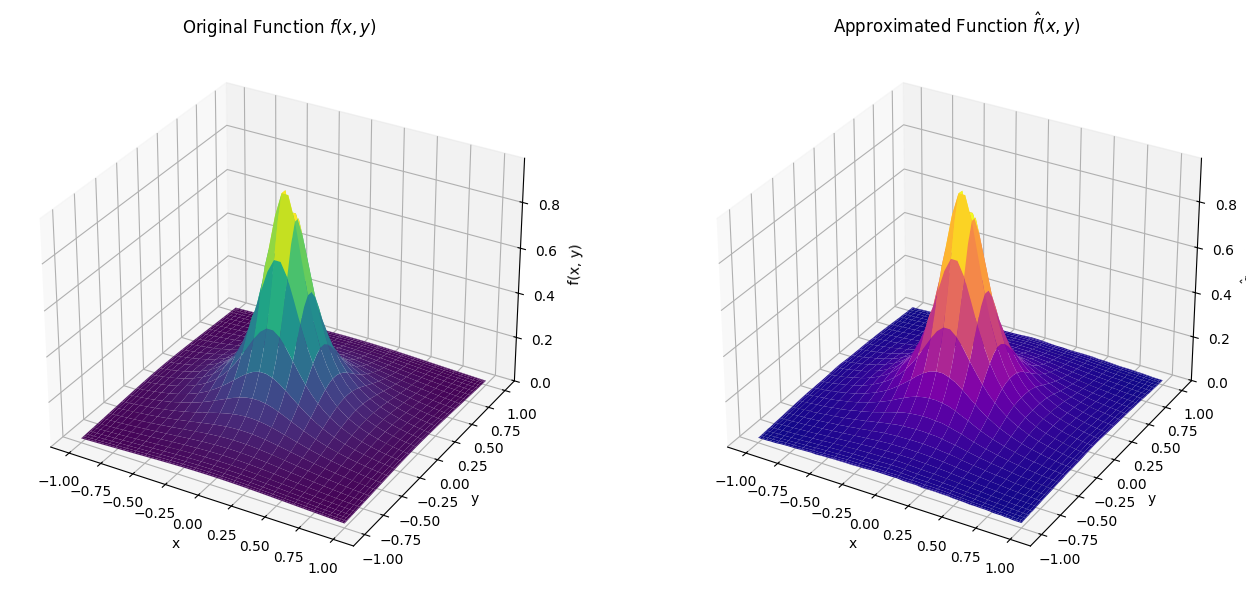

RMSE on [-1, 1]^2 uniform grid: 1.73e-01
L2 norm of reconstruction error: 5.05e-02


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/354238023.py:94: RuntimeWarning: divide by zero encountered in matmul
  A_eval_lin = Tx_lin @ A_opt         # (100, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/354238023.py:94: RuntimeWarning: overflow encountered in matmul
  A_eval_lin = Tx_lin @ A_opt         # (100, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/354238023.py:94: RuntimeWarning: invalid value encountered in matmul
  A_eval_lin = Tx_lin @ A_opt         # (100, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/354238023.py:95: RuntimeWarning: divide by zero encountered in matmul
  B_eval_lin = Ty_lin @ B_opt         # (100, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/354238023.py:95: RuntimeWarning: overflow encountered in matmul
  B_eval_lin = Ty_lin @ B_opt         # (100, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/354238023.py:95: RuntimeWarn

In [9]:
# BFGS optimization (without lambda)

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander
from scipy.optimize import minimize
from mpl_toolkits.mplot3d import Axes3D

# Function to approximate
def f(x, y, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2))

# Settings
N, M = 64, 64
d_x, d_y = 63, 63
R = 10

# Chebyshev nodes
x_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
y_nodes = np.cos(np.pi * np.arange(M) / (M - 1))
X, Y = np.meshgrid(x_nodes, y_nodes, indexing='ij')
F = f(X, Y)

# Chebyshev basis evaluations
Tx = chebvander(x_nodes, d_x)   # (N, d_x+1)
Ty = chebvander(y_nodes, d_y)   # (M, d_y+1)

# Helper functions to pack/unpack parameters
def pack_params(A, B):
    return np.concatenate([A.ravel(), B.ravel()])

def unpack_params(params):
    A_size = (d_x + 1) * R
    B_size = (d_y + 1) * R
    A = params[:A_size].reshape((d_x + 1, R))
    B = params[A_size:].reshape((d_y + 1, R))
    return A, B

# Loss function (mean squared error)
def loss(params):
    A, B = unpack_params(params)
    A_eval = Tx @ A       # (N, R)
    B_eval = Ty @ B       # (M, R)
    F_hat = sum(np.outer(A_eval[:, r], B_eval[:, r]) for r in range(R))
    return np.mean((F - F_hat)**2)

# Initialize A and B
np.random.seed(0)
A_init = 0.01 * np.random.randn(d_x + 1, R)
B_init = 0.01 * np.random.randn(d_y + 1, R)
params_init = pack_params(A_init, B_init)

# Optimize using BFGS
result = minimize(loss, params_init, method='BFGS', options={'maxiter': 10000, 'disp': True})

# Unpack optimized parameters
A_opt, B_opt = unpack_params(result.x)
A_eval = Tx @ A_opt
B_eval = Ty @ B_opt
F_hat = sum(np.outer(A_eval[:, r], B_eval[:, r]) for r in range(R))
rmse = np.sqrt(np.mean((F - F_hat)**2))
print(f"Final RMSE: {rmse:.2e}")

# Plot original and approximated function in 3D
fig = plt.figure(figsize=(14, 6))

# Plot original function
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X, Y, F, cmap='viridis', edgecolor='none')
ax1.set_title('Original Function $f(x, y)$')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x, y)')

# Plot approximated function
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X, Y, F_hat, cmap='plasma', edgecolor='none')
ax2.set_title('Approximated Function $\hat{f}(x, y)$')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('$\hat{f}(x, y)$')

plt.tight_layout()
plt.show()

# --- RMSE on [-1, 1]^2 uniform grid ---
x_lin = np.linspace(-1, 1, 100)
y_lin = np.linspace(-1, 1, 100)
X_lin, Y_lin = np.meshgrid(x_lin, y_lin, indexing='ij')

# Chebyshev basis at uniform grid
Tx_lin = chebvander(x_lin, d_x)     # (100, d_x+1)
Ty_lin = chebvander(y_lin, d_y)     # (100, d_y+1)
A_eval_lin = Tx_lin @ A_opt         # (100, R)
B_eval_lin = Ty_lin @ B_opt         # (100, R)

# Prediction on grid
F_pred_grid = sum(lambdas_opt[r] * np.outer(A_eval_lin[:, r], B_eval_lin[:, r]) for r in range(R))
F_true_grid = f(X_lin, Y_lin)

rmse_grid = np.sqrt(np.mean((F_pred_grid - F_true_grid) ** 2))
print(f"RMSE on [-1, 1]^2 uniform grid: {rmse_grid:.2e}")

# --- L2 norm of reconstruction error on Chebyshev nodes ---
l2_error = np.linalg.norm(F - F_hat)
print(f"L2 norm of reconstruction error: {l2_error:.2e}")

In [ ]:
# BFGS optimization (without lambda) in 3D

import numpy as np
from numpy.polynomial.chebyshev import chebvander
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# Function to approximate in 3D
def f(x, y, z, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2 + z**2))

# Settings
N = 64  # grid size in each dimension
d = N - 1  # Chebyshev degree
R = 5      # CP rank

# 1D Chebyshev nodes
nodes = np.cos(np.pi * np.arange(N) / (N - 1))
X, Y, Z = np.meshgrid(nodes, nodes, nodes, indexing='ij')
F = f(X, Y, Z)  # shape (N, N, N)

# Evaluate Chebyshev basis
T = chebvander(nodes, d)  # (N, d+1)

# Packing/unpacking helpers
def pack_params(A, B, C):
    return np.concatenate([A.ravel(), B.ravel(), C.ravel()])

def unpack_params(params):
    size = (d+1) * R
    A = params[:size].reshape((d+1, R))
    B = params[size:2*size].reshape((d+1, R))
    C = params[2*size:].reshape((d+1, R))
    return A, B, C

# Loss function
def loss(params):
    A, B, C = unpack_params(params)
    Ax = T @ A   # (N, R)
    By = T @ B
    Cz = T @ C
    F_hat = np.zeros((N, N, N))
    for r in range(R):
        F_hat += np.einsum('i,j,k->ijk', Ax[:, r], By[:, r], Cz[:, r])
    return np.mean((F - F_hat)**2)

# Initialize parameters
np.random.seed(0)
A_init = 0.01 * np.random.randn(d+1, R)
B_init = 0.01 * np.random.randn(d+1, R)
C_init = 0.01 * np.random.randn(d+1, R)
params_init = pack_params(A_init, B_init, C_init)

# Optimize
result = minimize(loss, params_init, method='BFGS', options={'maxiter': 1000, 'disp': True})
A_opt, B_opt, C_opt = unpack_params(result.x)

# Final reconstruction
Ax = T @ A_opt
By = T @ B_opt
Cz = T @ C_opt
F_hat = np.zeros((N, N, N))
for r in range(R):
    F_hat += np.einsum('i,j,k->ijk', Ax[:, r], By[:, r], Cz[:, r])

rmse = np.sqrt(np.mean((F - F_hat)**2))
print(f"Final RMSE: {rmse:.2e}")

# Visualize slices at z = 0
z_index = N // 2
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(F[:, :, z_index], extent=[-1, 1, -1, 1], origin='lower', cmap='viridis')
axs[0].set_title("Original f(x, y, z=0)")
axs[1].imshow(F_hat[:, :, z_index], extent=[-1, 1, -1, 1], origin='lower', cmap='plasma')
axs[1].set_title("Approximated $\hat{f}(x, y, z=0)$")
plt.tight_layout()
plt.show()


<>:75: SyntaxWarning: invalid escape sequence '\h'
<>:75: SyntaxWarning: invalid escape sequence '\h'
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_59035/695230268.py:75: SyntaxWarning: invalid escape sequence '\h'
  axs[1].set_title("Approximated $\hat{f}(x, y, z=0)$")
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_59035/695230268.py:39: RuntimeWarning: divide by zero encountered in matmul
  Ax = T @ A   # (N, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_59035/695230268.py:39: RuntimeWarning: overflow encountered in matmul
  Ax = T @ A   # (N, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_59035/695230268.py:39: RuntimeWarning: invalid value encountered in matmul
  Ax = T @ A   # (N, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_59035/695230268.py:40: RuntimeWarning: divide by zero encountered in matmul
  By = T @ B
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_59035/695230268.py:40: RuntimeWarning: 

<>:77: SyntaxWarning: invalid escape sequence '\h'
<>:80: SyntaxWarning: invalid escape sequence '\h'
<>:77: SyntaxWarning: invalid escape sequence '\h'
<>:80: SyntaxWarning: invalid escape sequence '\h'
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/1664882056.py:77: SyntaxWarning: invalid escape sequence '\h'
  ax2.set_title('Approximated Function $\hat{f}(x, y)$')
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/1664882056.py:80: SyntaxWarning: invalid escape sequence '\h'
  ax2.set_zlabel('$\hat{f}(x, y)$')
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/1664882056.py:40: RuntimeWarning: divide by zero encountered in matmul
  A_eval = Tx @ A       # (N, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/1664882056.py:40: RuntimeWarning: overflow encountered in matmul
  A_eval = Tx @ A       # (N, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/1664882056.py:40: RuntimeWarning: invalid value enco

         Current function value: 0.000474
         Iterations: 150
         Function evaluations: 427332
         Gradient evaluations: 331
Final RMSE: 2.18e-02


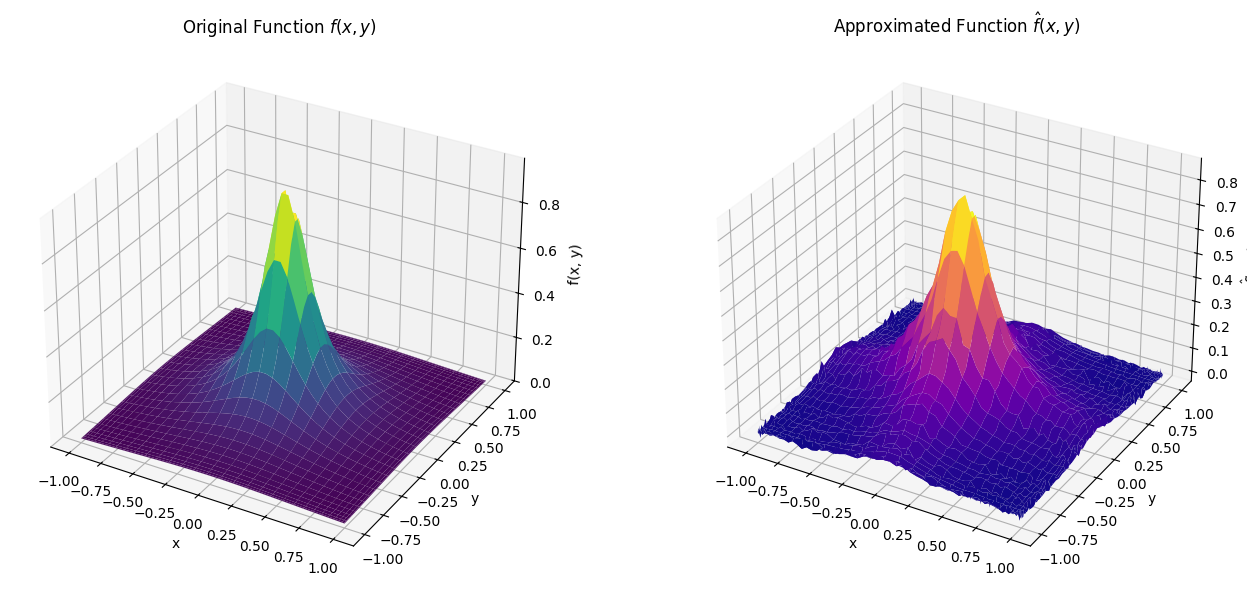

In [ ]:
# CG optimization (with lambda) in 2D

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander
from scipy.optimize import minimize

# Function to approximate
def f(x, y, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2))

# Settings
N, M = 64, 64
d_x, d_y = 63, 63
R = 10

# Chebyshev nodes
x_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
y_nodes = np.cos(np.pi * np.arange(M) / (M - 1))
X, Y = np.meshgrid(x_nodes, y_nodes, indexing='ij')
F = f(X, Y)

# Basis matrices
Tx = chebvander(x_nodes, d_x)   # (N, d_x+1)
Ty = chebvander(y_nodes, d_y)   # (M, d_y+1)

# Vectorize inputs for optimization
def pack_params(A, B, lambdas):
    return np.concatenate([A.ravel(), B.ravel(), lambdas])

def unpack_params(params):
    A_size = (d_x + 1) * R
    B_size = (d_y + 1) * R
    A = params[:A_size].reshape((d_x + 1, R))
    B = params[A_size:A_size + B_size].reshape((d_y + 1, R))
    lambdas = params[-R:]
    return A, B, lambdas

# Full objective function (RMSE)
def loss(params):
    A, B, lambdas = unpack_params(params)
    A_eval = Tx @ A       # (N, R)
    B_eval = Ty @ B       # (M, R)
    F_hat = sum(lambdas[r] * np.outer(A_eval[:, r], B_eval[:, r]) for r in range(R))
    return np.mean((F - F_hat)**2)

# Initialize parameters
A_init = np.random.randn(d_x + 1, R)
B_init = np.random.randn(d_y + 1, R)
lambdas_init = np.ones(R)
params_init = pack_params(A_init, B_init, lambdas_init)

# Optimization using L-BFGS-B
result = minimize(loss, params_init, method='CG', options={'maxiter': 1000, 'disp': True})

# Unpack final result
A_opt, B_opt, lambdas_opt = unpack_params(result.x)

# Final evaluation
A_eval = Tx @ A_opt
B_eval = Ty @ B_opt
F_hat = sum(lambdas_opt[r] * np.outer(A_eval[:, r], B_eval[:, r]) for r in range(R))
rmse = np.sqrt(np.mean((F - F_hat)**2))
print(f"Final RMSE: {rmse:.2e}")

fig = plt.figure(figsize=(14, 6))

# 3D plot of original function F
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X, Y, F, cmap='viridis', edgecolor='none')
ax1.set_title('Original Function $f(x, y)$')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x, y)')

# 3D plot of approximated function F_hat
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X, Y, F_hat, cmap='plasma', edgecolor='none')
ax2.set_title('Approximated Function $\hat{f}(x, y)$')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('$\hat{f}(x, y)$')

plt.tight_layout()
plt.show()


<>:78: SyntaxWarning: invalid escape sequence '\h'
<>:81: SyntaxWarning: invalid escape sequence '\h'
<>:78: SyntaxWarning: invalid escape sequence '\h'
<>:81: SyntaxWarning: invalid escape sequence '\h'
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/472581682.py:78: SyntaxWarning: invalid escape sequence '\h'
  ax2.set_title('Approximated Function $\hat{f}(x, y)$')
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/472581682.py:81: SyntaxWarning: invalid escape sequence '\h'
  ax2.set_zlabel('$\hat{f}(x, y)$')
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/472581682.py:42: RuntimeWarning: divide by zero encountered in matmul
  A_eval = Tx @ A       # (N, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/472581682.py:42: RuntimeWarning: overflow encountered in matmul
  A_eval = Tx @ A       # (N, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/472581682.py:42: RuntimeWarning: invalid value encounter

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 71
         Function evaluations: 187026
         Gradient evaluations: 146
Final RMSE: 6.20e-04


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/472581682.py:58: RuntimeWarning: divide by zero encountered in matmul
  A_eval = Tx @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/472581682.py:58: RuntimeWarning: overflow encountered in matmul
  A_eval = Tx @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/472581682.py:58: RuntimeWarning: invalid value encountered in matmul
  A_eval = Tx @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/472581682.py:59: RuntimeWarning: divide by zero encountered in matmul
  B_eval = Ty @ B_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/472581682.py:59: RuntimeWarning: overflow encountered in matmul
  B_eval = Ty @ B_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/472581682.py:59: RuntimeWarning: invalid value encountered in matmul
  B_eval = Ty @ B_opt


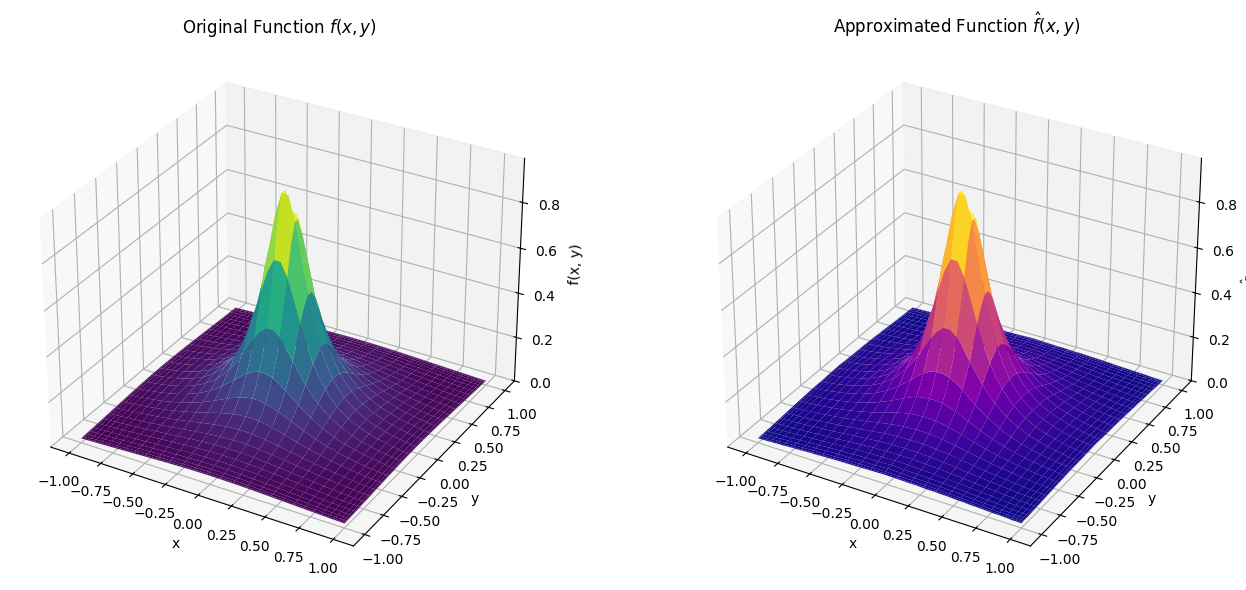

In [ ]:
# BFGS optimization (without lambda)

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander
from scipy.optimize import minimize
from mpl_toolkits.mplot3d import Axes3D

# Function to approximate
def f(x, y, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2))

# Settings
N, M = 64, 64
d_x, d_y = 63, 63
R = 10

# Chebyshev nodes
x_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
y_nodes = np.cos(np.pi * np.arange(M) / (M - 1))
X, Y = np.meshgrid(x_nodes, y_nodes, indexing='ij')
F = f(X, Y)

# Chebyshev basis evaluations
Tx = chebvander(x_nodes, d_x)   # (N, d_x+1)
Ty = chebvander(y_nodes, d_y)   # (M, d_y+1)

# Helper functions to pack/unpack parameters
def pack_params(A, B):
    return np.concatenate([A.ravel(), B.ravel()])

def unpack_params(params):
    A_size = (d_x + 1) * R
    B_size = (d_y + 1) * R
    A = params[:A_size].reshape((d_x + 1, R))
    B = params[A_size:].reshape((d_y + 1, R))
    return A, B

# Loss function (mean squared error)
def loss(params):
    A, B = unpack_params(params)
    A_eval = Tx @ A       # (N, R)
    B_eval = Ty @ B       # (M, R)
    F_hat = sum(np.outer(A_eval[:, r], B_eval[:, r]) for r in range(R))
    return np.mean((F - F_hat)**2)

# Initialize A and B
np.random.seed(0)
A_init = 0.01 * np.random.randn(d_x + 1, R)
B_init = 0.01 * np.random.randn(d_y + 1, R)
params_init = pack_params(A_init, B_init)

# Optimize using BFGS
result = minimize(loss, params_init, method='CG', options={'maxiter': 10000, 'disp': True})

# Unpack optimized parameters
A_opt, B_opt = unpack_params(result.x)
A_eval = Tx @ A_opt
B_eval = Ty @ B_opt
F_hat = sum(np.outer(A_eval[:, r], B_eval[:, r]) for r in range(R))
rmse = np.sqrt(np.mean((F - F_hat)**2))
print(f"Final RMSE: {rmse:.2e}")

# Plot original and approximated function in 3D
fig = plt.figure(figsize=(14, 6))

# Plot original function
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X, Y, F, cmap='viridis', edgecolor='none')
ax1.set_title('Original Function $f(x, y)$')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x, y)')

# Plot approximated function
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X, Y, F_hat, cmap='plasma', edgecolor='none')
ax2.set_title('Approximated Function $\hat{f}(x, y)$')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('$\hat{f}(x, y)$')

plt.tight_layout()
plt.show()


<>:104: SyntaxWarning: invalid escape sequence '\h'
<>:107: SyntaxWarning: invalid escape sequence '\h'
<>:104: SyntaxWarning: invalid escape sequence '\h'
<>:107: SyntaxWarning: invalid escape sequence '\h'
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2449703028.py:104: SyntaxWarning: invalid escape sequence '\h'
  ax2.set_title('Approximated Function $\hat{f}(x, y)$')
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2449703028.py:107: SyntaxWarning: invalid escape sequence '\h'
  ax2.set_zlabel('$\hat{f}(x, y)$')
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2449703028.py:48: RuntimeWarning: divide by zero encountered in matmul
  A_eval = Tx_a @ A       # (N, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2449703028.py:48: RuntimeWarning: overflow encountered in matmul
  A_eval = Tx_a @ A       # (N, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2449703028.py:48: RuntimeWarning: invalid 

Iteration    1: Loss = 1.3083e-02
Iteration   50: Loss = 2.8346e-05
Iteration  100: Loss = 1.8112e-07
Iteration  150: Loss = 3.4107e-08
Iteration  200: Loss = 2.7595e-06
Iteration  250: Loss = 9.5843e-09
Iteration  300: Loss = 1.1727e-06
Iteration  350: Loss = 1.2470e-07
Iteration  400: Loss = 3.4159e-05
Iteration  450: Loss = 3.0493e-07
Iteration  500: Loss = 6.9432e-09
Final RMSE: 8.33e-05


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2449703028.py:87: RuntimeWarning: divide by zero encountered in matmul
  A_eval = Tx @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2449703028.py:87: RuntimeWarning: overflow encountered in matmul
  A_eval = Tx @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2449703028.py:87: RuntimeWarning: invalid value encountered in matmul
  A_eval = Tx @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2449703028.py:88: RuntimeWarning: divide by zero encountered in matmul
  B_eval = Ty @ B_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2449703028.py:88: RuntimeWarning: overflow encountered in matmul
  B_eval = Ty @ B_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2449703028.py:88: RuntimeWarning: invalid value encountered in matmul
  B_eval = Ty @ B_opt


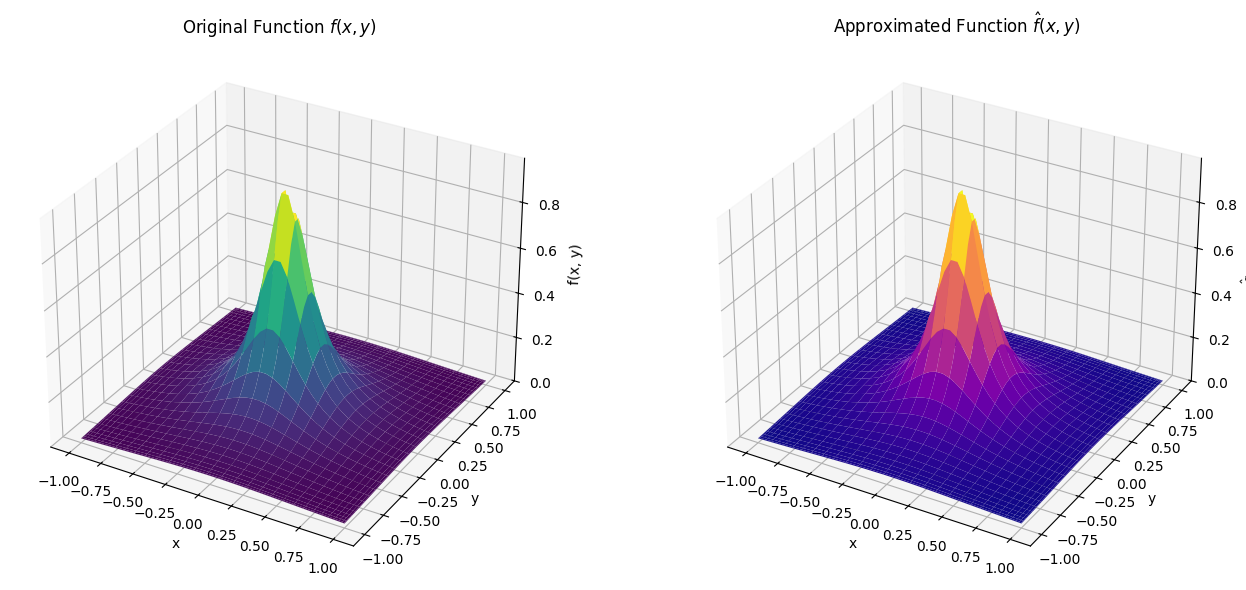

RMSE on [-1, 1]^2 uniform grid: 8.59e-05
L2 norm of reconstruction error: 5.33e-03


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2449703028.py:121: RuntimeWarning: divide by zero encountered in matmul
  A_eval_lin = Tx_lin @ A_opt         # (100, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2449703028.py:121: RuntimeWarning: overflow encountered in matmul
  A_eval_lin = Tx_lin @ A_opt         # (100, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2449703028.py:121: RuntimeWarning: invalid value encountered in matmul
  A_eval_lin = Tx_lin @ A_opt         # (100, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2449703028.py:122: RuntimeWarning: divide by zero encountered in matmul
  B_eval_lin = Ty_lin @ B_opt         # (100, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2449703028.py:122: RuntimeWarning: overflow encountered in matmul
  B_eval_lin = Ty_lin @ B_opt         # (100, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_60857/2449703028.py:122:

In [11]:
# Adam optimization (with autograd) in 2D

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander
from autograd import grad
import autograd.numpy as anp

# Function to approximate
def f(x, y, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2))

# Settings
N, M = 64, 64
d_x, d_y = 63, 63
R = 10
lr = 1e-2
num_iters = 500

# Chebyshev nodes
x_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
y_nodes = np.cos(np.pi * np.arange(M) / (M - 1))
X, Y = np.meshgrid(x_nodes, y_nodes, indexing='ij')
F = f(X, Y)
F_autograd = anp.array(F)

# Basis matrices (not differentiable, use regular numpy)
Tx = chebvander(x_nodes, d_x)   # (N, d_x+1)
Ty = chebvander(y_nodes, d_y)   # (M, d_y+1)
Tx_a = anp.array(Tx)
Ty_a = anp.array(Ty)

# Vectorize parameters
def pack_params(A, B, lambdas):
    return anp.concatenate([A.ravel(), B.ravel(), lambdas])

def unpack_params(params):
    A_size = (d_x + 1) * R
    B_size = (d_y + 1) * R
    A = params[:A_size].reshape((d_x + 1, R))
    B = params[A_size:A_size + B_size].reshape((d_y + 1, R))
    lambdas = params[-R:]
    return A, B, lambdas

# Loss function using autograd.numpy
def loss(params):
    A, B, lambdas = unpack_params(params)
    A_eval = Tx_a @ A       # (N, R)
    B_eval = Ty_a @ B       # (M, R)
    F_hat = sum(lambdas[r] * anp.outer(A_eval[:, r], B_eval[:, r]) for r in range(R))
    return anp.mean((F_autograd - F_hat)**2)

# Adam optimizer
def adam_update(params, grads, m, v, t, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
    m = beta1 * m + (1 - beta1) * grads
    v = beta2 * v + (1 - beta2) * (grads ** 2)
    m_hat = m / (1 - beta1 ** t)
    v_hat = v / (1 - beta2 ** t)
    params -= lr * m_hat / (anp.sqrt(v_hat) + eps)
    return params, m, v

# Initialize parameters
np.random.seed(42)
A_init = 0.01 * np.random.randn(d_x + 1, R)
B_init = 0.01 * np.random.randn(d_y + 1, R)
lambdas_init = np.ones(R)
params = pack_params(A_init, B_init, lambdas_init)

# Adam state
m = anp.zeros_like(params)
v = anp.zeros_like(params)

# Gradient function
grad_loss = grad(loss)

# Optimization loop
for t in range(1, num_iters + 1):
    grads = grad_loss(params)
    params, m, v = adam_update(params, grads, m, v, t, lr=lr)
    
    if t % 50 == 0 or t == 1:
        l = loss(params)
        print(f"Iteration {t:4d}: Loss = {l:.4e}")

# Final results
A_opt, B_opt, lambdas_opt = unpack_params(params)
A_eval = Tx @ A_opt
B_eval = Ty @ B_opt
F_hat = sum(lambdas_opt[r] * np.outer(A_eval[:, r], B_eval[:, r]) for r in range(R))
rmse = np.sqrt(np.mean((F - F_hat)**2))
print(f"Final RMSE: {rmse:.2e}")

# Visualization
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X, Y, F, cmap='viridis', edgecolor='none')
ax1.set_title('Original Function $f(x, y)$')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x, y)')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X, Y, F_hat, cmap='plasma', edgecolor='none')
ax2.set_title('Approximated Function $\hat{f}(x, y)$')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('$\hat{f}(x, y)$')

plt.tight_layout()
plt.show()


# --- RMSE on [-1, 1]^2 uniform grid ---
x_lin = np.linspace(-1, 1, 100)
y_lin = np.linspace(-1, 1, 100)
X_lin, Y_lin = np.meshgrid(x_lin, y_lin, indexing='ij')

# Evaluate Chebyshev basis on the linspace grid
Tx_lin = chebvander(x_lin, d_x)     # (100, d_x+1)
Ty_lin = chebvander(y_lin, d_y)     # (100, d_y+1)
A_eval_lin = Tx_lin @ A_opt         # (100, R)
B_eval_lin = Ty_lin @ B_opt         # (100, R)

# Predict on uniform grid
F_pred_grid = sum(lambdas_opt[r] * np.outer(A_eval_lin[:, r], B_eval_lin[:, r]) for r in range(R))
F_true_grid = f(X_lin, Y_lin)

# Compute RMSE on uniform grid
rmse_grid = np.sqrt(np.mean((F_pred_grid - F_true_grid) ** 2))
print(f"RMSE on [-1, 1]^2 uniform grid: {rmse_grid:.2e}")

# --- L2 norm of reconstruction error on Chebyshev grid ---
l2_error = np.linalg.norm(F - F_hat)
print(f"L2 norm of reconstruction error: {l2_error:.2e}")



Rank R = 1
Final RMSE for R=1: 2.1230e-02

Rank R = 2


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/3969052772.py:80: RuntimeWarning: divide by zero encountered in matmul
  A_eval = Tx @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/3969052772.py:80: RuntimeWarning: overflow encountered in matmul
  A_eval = Tx @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/3969052772.py:80: RuntimeWarning: invalid value encountered in matmul
  A_eval = Tx @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/3969052772.py:81: RuntimeWarning: divide by zero encountered in matmul
  B_eval = Ty @ B_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/3969052772.py:81: RuntimeWarning: overflow encountered in matmul
  B_eval = Ty @ B_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/3969052772.py:81: RuntimeWarning: invalid value encountered in matmul
  B_eval = Ty @ B_opt


Final RMSE for R=2: 3.9861e-03

Rank R = 3
Final RMSE for R=3: 7.1438e-04

Rank R = 4
Final RMSE for R=4: 6.9816e-04

Rank R = 5
Final RMSE for R=5: 3.1394e-03

Rank R = 6
Final RMSE for R=6: 4.6332e-03

Rank R = 7
Final RMSE for R=7: 1.1177e-04

Rank R = 8
Final RMSE for R=8: 5.8147e-05

Rank R = 9
Final RMSE for R=9: 6.9710e-05

Rank R = 10
Final RMSE for R=10: 8.3326e-05

Rank R = 11
Final RMSE for R=11: 4.4851e-04

Rank R = 12
Final RMSE for R=12: 7.9189e-05

Rank R = 13
Final RMSE for R=13: 1.5162e-03

Rank R = 14
Final RMSE for R=14: 1.7063e-03

Rank R = 15
Final RMSE for R=15: 1.6388e-04

Rank R = 16
Final RMSE for R=16: 5.1545e-03

Rank R = 17
Final RMSE for R=17: 1.0700e-03

Rank R = 18
Final RMSE for R=18: 7.0745e-04

Rank R = 19
Final RMSE for R=19: 2.2976e-05

Rank R = 20
Final RMSE for R=20: 1.1221e-03


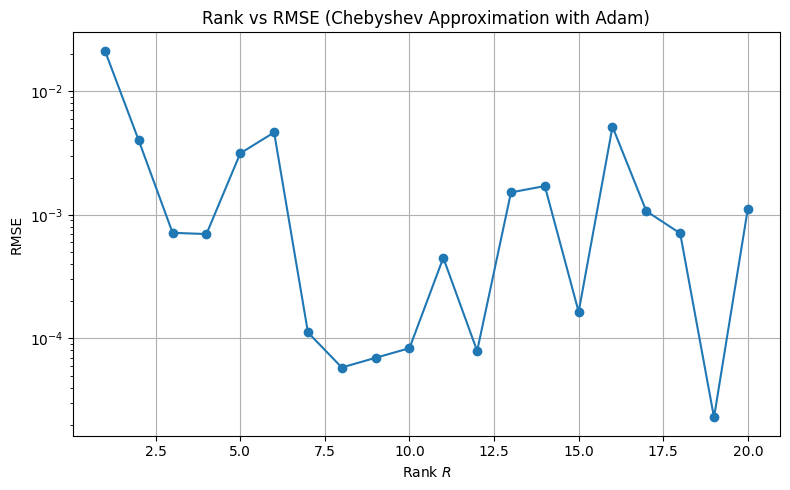

In [ ]:
# Rank v/s RMSE plot

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander
from autograd import grad
import autograd.numpy as anp

# Function to approximate
def f(x, y, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2))

# Settings
N, M = 64, 64
d_x, d_y = 63, 63
lr = 1e-2
num_iters = 500

# Chebyshev nodes and evaluations
x_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
y_nodes = np.cos(np.pi * np.arange(M) / (M - 1))
X, Y = np.meshgrid(x_nodes, y_nodes, indexing='ij')
F = f(X, Y)
F_autograd = anp.array(F)
Tx = chebvander(x_nodes, d_x)
Ty = chebvander(y_nodes, d_y)
Tx_a = anp.array(Tx)
Ty_a = anp.array(Ty)

# Parameter helpers
def pack_params(A, B, lambdas):
    return anp.concatenate([A.ravel(), B.ravel(), lambdas])

def unpack_params(params, R):
    A_size = (d_x + 1) * R
    B_size = (d_y + 1) * R
    A = params[:A_size].reshape((d_x + 1, R))
    B = params[A_size:A_size + B_size].reshape((d_y + 1, R))
    lambdas = params[-R:]
    return A, B, lambdas

# Loss function
def loss_fn(params, R):
    A, B, lambdas = unpack_params(params, R)
    A_eval = Tx_a @ A       # (N, R)
    B_eval = Ty_a @ B       # (M, R)
    F_hat = sum(lambdas[r] * anp.outer(A_eval[:, r], B_eval[:, r]) for r in range(R))
    return anp.mean((F_autograd - F_hat)**2)

# Adam update
def adam_update(params, grads, m, v, t, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
    m = beta1 * m + (1 - beta1) * grads
    v = beta2 * v + (1 - beta2) * (grads ** 2)
    m_hat = m / (1 - beta1 ** t)
    v_hat = v / (1 - beta2 ** t)
    params -= lr * m_hat / (anp.sqrt(v_hat) + eps)
    return params, m, v

# Track RMSE vs Rank
ranks = range(1, 21)
rmses = []

for R in ranks:
    print(f"\nRank R = {R}")
    np.random.seed(42)
    A_init = 0.01 * np.random.randn(d_x + 1, R)
    B_init = 0.01 * np.random.randn(d_y + 1, R)
    lambdas_init = np.ones(R)
    params = pack_params(A_init, B_init, lambdas_init)

    m = anp.zeros_like(params)
    v = anp.zeros_like(params)
    grad_loss = grad(lambda p: loss_fn(p, R))

    for t in range(1, num_iters + 1):
        grads = grad_loss(params)
        params, m, v = adam_update(params, grads, m, v, t, lr=lr)
    
    A_opt, B_opt, lambdas_opt = unpack_params(params, R)
    A_eval = Tx @ A_opt
    B_eval = Ty @ B_opt
    F_hat = sum(lambdas_opt[r] * np.outer(A_eval[:, r], B_eval[:, r]) for r in range(R))
    rmse = np.sqrt(np.mean((F - F_hat)**2))
    print(f"Final RMSE for R={R}: {rmse:.4e}")
    rmses.append(rmse)

# Plot Rank vs RMSE
plt.figure(figsize=(8, 5))
plt.plot(ranks, rmses, marker='o')
plt.xscale('linear')
plt.yscale('log')
plt.xlabel('Rank $R$')
plt.ylabel('RMSE')
plt.title('Rank vs RMSE (Chebyshev Approximation with Adam)')
plt.grid(True)
plt.tight_layout()
plt.show()


<>:104: SyntaxWarning: invalid escape sequence '\h'
<>:104: SyntaxWarning: invalid escape sequence '\h'
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/1534415060.py:104: SyntaxWarning: invalid escape sequence '\h'
  axs[1].set_title("Approximated $\hat{f}(x, y, z=0)$")
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/1534415060.py:47: RuntimeWarning: divide by zero encountered in matmul
  Ax = Tx @ A  # (N, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/1534415060.py:47: RuntimeWarning: overflow encountered in matmul
  Ax = Tx @ A  # (N, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/1534415060.py:47: RuntimeWarning: invalid value encountered in matmul
  Ax = Tx @ A  # (N, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/1534415060.py:48: RuntimeWarning: divide by zero encountered in matmul
  By = Ty @ B
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/1534415060.py:48: Runtim

Iteration    1: Loss = 2.4994e-03
Iteration   50: Loss = 1.4160e-05
Iteration  100: Loss = 3.8044e-07
Iteration  150: Loss = 1.0819e-07
Iteration  200: Loss = 6.5092e-07
Iteration  250: Loss = 5.9519e-08
Iteration  300: Loss = 1.0010e-07
Iteration  350: Loss = 1.4906e-06
Iteration  400: Loss = 4.6703e-06
Iteration  450: Loss = 5.1510e-07
Iteration  500: Loss = 1.4842e-07
Final RMSE: 3.85e-04


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/1534415060.py:89: RuntimeWarning: divide by zero encountered in matmul
  Ax = T @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/1534415060.py:89: RuntimeWarning: overflow encountered in matmul
  Ax = T @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/1534415060.py:89: RuntimeWarning: invalid value encountered in matmul
  Ax = T @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/1534415060.py:90: RuntimeWarning: divide by zero encountered in matmul
  By = T @ B_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/1534415060.py:90: RuntimeWarning: overflow encountered in matmul
  By = T @ B_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/1534415060.py:90: RuntimeWarning: invalid value encountered in matmul
  By = T @ B_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/1534415060.py:91: RuntimeWarnin

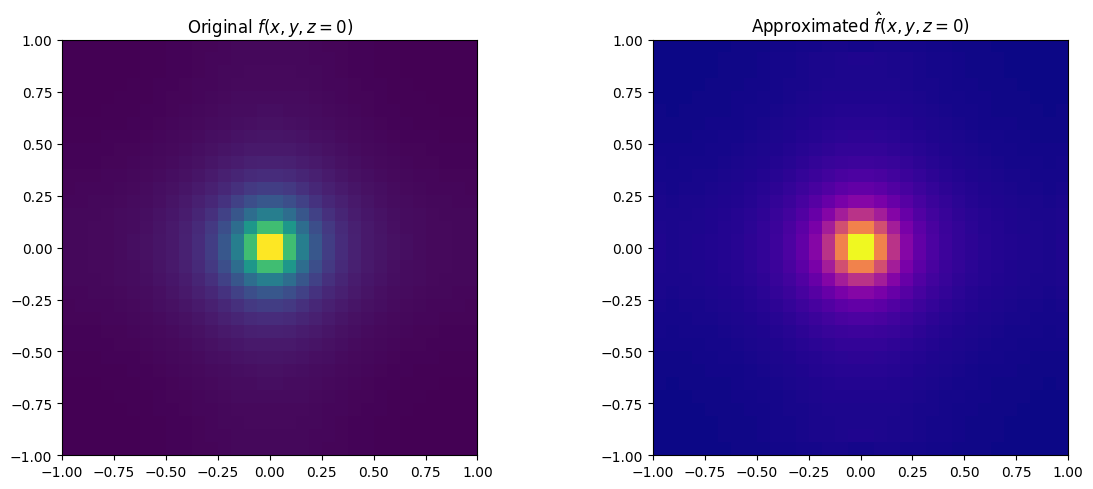

In [ ]:
# Adam optimization (with autograd) in 3D with 32x32x32 grid

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander
from autograd import grad
import autograd.numpy as anp

# Function to approximate
def f(x, y, z, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2 + z**2))

# Settings
N = 32
d = N - 1
R = 10
lr = 1e-2
num_iters = 500

# Chebyshev nodes
nodes = np.cos(np.pi * np.arange(N) / (N - 1))
X, Y, Z = np.meshgrid(nodes, nodes, nodes, indexing='ij')
F = f(X, Y, Z)
F_autograd = anp.array(F)

# Chebyshev basis
T = chebvander(nodes, d)  # shape (N, d+1)
Tx = anp.array(T)
Ty = anp.array(T)
Tz = anp.array(T)

# Vectorize params
def pack_params(A, B, C, lambdas):
    return anp.concatenate([A.ravel(), B.ravel(), C.ravel(), lambdas])

def unpack_params(params):
    size = (d+1) * R
    A = params[:size].reshape((d+1, R))
    B = params[size:2*size].reshape((d+1, R))
    C = params[2*size:3*size].reshape((d+1, R))
    lambdas = params[3*size:]
    return A, B, C, lambdas

# Loss function
def loss(params):
    A, B, C, lambdas = unpack_params(params)
    Ax = Tx @ A  # (N, R)
    By = Ty @ B
    Cz = Tz @ C
    F_hat = anp.zeros((N, N, N))
    for r in range(R):
        F_hat += lambdas[r] * anp.einsum('i,j,k->ijk', Ax[:, r], By[:, r], Cz[:, r])
    return anp.mean((F_autograd - F_hat)**2)

# Adam optimizer
def adam_update(params, grads, m, v, t, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
    m = beta1 * m + (1 - beta1) * grads
    v = beta2 * v + (1 - beta2) * (grads ** 2)
    m_hat = m / (1 - beta1 ** t)
    v_hat = v / (1 - beta2 ** t)
    params -= lr * m_hat / (anp.sqrt(v_hat) + eps)
    return params, m, v

# Init
np.random.seed(42)
A_init = 0.01 * np.random.randn(d+1, R)
B_init = 0.01 * np.random.randn(d+1, R)
C_init = 0.01 * np.random.randn(d+1, R)
lambdas_init = np.ones(R)
params = pack_params(A_init, B_init, C_init, lambdas_init)

# Adam state
m = anp.zeros_like(params)
v = anp.zeros_like(params)

# Gradient function
grad_loss = grad(loss)

# Optimization loop
for t in range(1, num_iters + 1):
    grads = grad_loss(params)
    params, m, v = adam_update(params, grads, m, v, t, lr=lr)
    if t % 50 == 0 or t == 1:
        l = loss(params)
        print(f"Iteration {t:4d}: Loss = {l:.4e}")

# Final evaluation
A_opt, B_opt, C_opt, lambdas_opt = unpack_params(params)
Ax = T @ A_opt
By = T @ B_opt
Cz = T @ C_opt
F_hat = np.zeros((N, N, N))
for r in range(R):
    F_hat += lambdas_opt[r] * np.einsum('i,j,k->ijk', Ax[:, r], By[:, r], Cz[:, r])
rmse = np.sqrt(np.mean((F - F_hat)**2))
print(f"Final RMSE: {rmse:.2e}")

# Visualization: slice at z = 0
z_index = N // 2
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(F[:, :, z_index], extent=[-1, 1, -1, 1], origin='lower', cmap='viridis')
axs[0].set_title("Original $f(x, y, z=0)$")
axs[1].imshow(F_hat[:, :, z_index], extent=[-1, 1, -1, 1], origin='lower', cmap='plasma')
axs[1].set_title("Approximated $\hat{f}(x, y, z=0)$")
plt.tight_layout()
plt.show()


<>:104: SyntaxWarning: invalid escape sequence '\h'
<>:104: SyntaxWarning: invalid escape sequence '\h'
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2170558674.py:104: SyntaxWarning: invalid escape sequence '\h'
  axs[1].set_title("Approximated $\hat{f}(x, y, z=0)$")
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2170558674.py:47: RuntimeWarning: divide by zero encountered in matmul
  Ax = Tx @ A  # (N, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2170558674.py:47: RuntimeWarning: overflow encountered in matmul
  Ax = Tx @ A  # (N, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2170558674.py:47: RuntimeWarning: invalid value encountered in matmul
  Ax = Tx @ A  # (N, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2170558674.py:48: RuntimeWarning: divide by zero encountered in matmul
  By = Ty @ B
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2170558674.py:48: Runtim

Iteration    1: Loss = 2.5959e-03
Iteration   50: Loss = 1.3120e-05
Iteration  100: Loss = 5.5966e-07
Iteration  150: Loss = 4.3186e-06
Iteration  200: Loss = 3.3008e-07
Iteration  250: Loss = 3.8195e-07
Iteration  300: Loss = 1.3655e-06
Iteration  350: Loss = 3.4636e-07
Iteration  400: Loss = 2.6321e-08
Iteration  450: Loss = 3.6787e-07
Iteration  500: Loss = 9.9634e-08
Final RMSE: 3.16e-04


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2170558674.py:89: RuntimeWarning: divide by zero encountered in matmul
  Ax = T @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2170558674.py:89: RuntimeWarning: overflow encountered in matmul
  Ax = T @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2170558674.py:89: RuntimeWarning: invalid value encountered in matmul
  Ax = T @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2170558674.py:90: RuntimeWarning: divide by zero encountered in matmul
  By = T @ B_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2170558674.py:90: RuntimeWarning: overflow encountered in matmul
  By = T @ B_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2170558674.py:90: RuntimeWarning: invalid value encountered in matmul
  By = T @ B_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2170558674.py:91: RuntimeWarnin

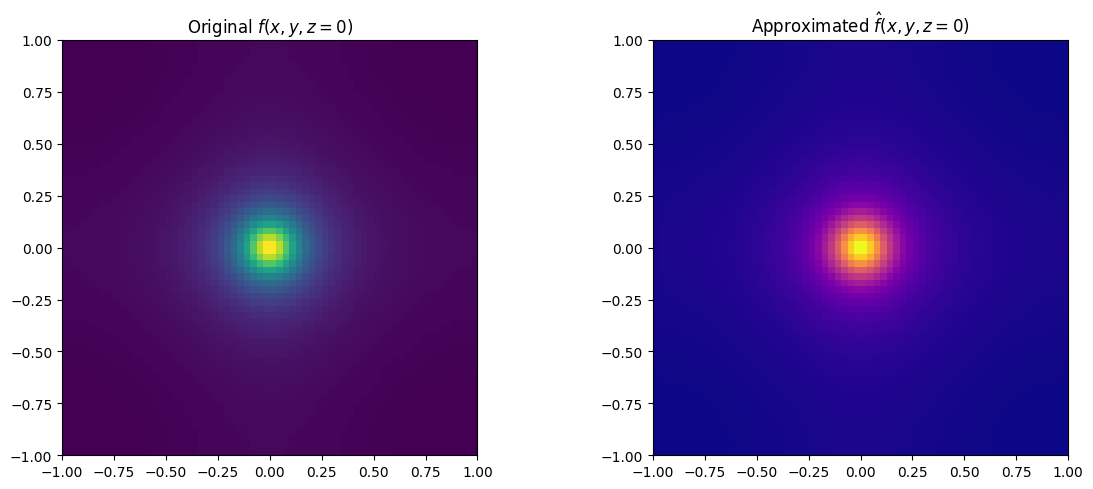

In [ ]:
# Adam optimization (with autograd) in 3D with 64x64x64 grid

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander
from autograd import grad
import autograd.numpy as anp

# Function to approximate
def f(x, y, z, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2 + z**2))

# Settings
N = 64
d = N - 1
R = 10
lr = 1e-2
num_iters = 500

# Chebyshev nodes
nodes = np.cos(np.pi * np.arange(N) / (N - 1))
X, Y, Z = np.meshgrid(nodes, nodes, nodes, indexing='ij')
F = f(X, Y, Z)
F_autograd = anp.array(F)

# Chebyshev basis
T = chebvander(nodes, d)  # shape (N, d+1)
Tx = anp.array(T)
Ty = anp.array(T)
Tz = anp.array(T)

# Vectorize params
def pack_params(A, B, C, lambdas):
    return anp.concatenate([A.ravel(), B.ravel(), C.ravel(), lambdas])

def unpack_params(params):
    size = (d+1) * R
    A = params[:size].reshape((d+1, R))
    B = params[size:2*size].reshape((d+1, R))
    C = params[2*size:3*size].reshape((d+1, R))
    lambdas = params[3*size:]
    return A, B, C, lambdas

# Loss function
def loss(params):
    A, B, C, lambdas = unpack_params(params)
    Ax = Tx @ A  # (N, R)
    By = Ty @ B
    Cz = Tz @ C
    F_hat = anp.zeros((N, N, N))
    for r in range(R):
        F_hat += lambdas[r] * anp.einsum('i,j,k->ijk', Ax[:, r], By[:, r], Cz[:, r])
    return anp.mean((F_autograd - F_hat)**2)

# Adam optimizer
def adam_update(params, grads, m, v, t, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
    m = beta1 * m + (1 - beta1) * grads
    v = beta2 * v + (1 - beta2) * (grads ** 2)
    m_hat = m / (1 - beta1 ** t)
    v_hat = v / (1 - beta2 ** t)
    params -= lr * m_hat / (anp.sqrt(v_hat) + eps)
    return params, m, v

# Init
np.random.seed(42)
A_init = 0.01 * np.random.randn(d+1, R)
B_init = 0.01 * np.random.randn(d+1, R)
C_init = 0.01 * np.random.randn(d+1, R)
lambdas_init = np.ones(R)
params = pack_params(A_init, B_init, C_init, lambdas_init)

# Adam state
m = anp.zeros_like(params)
v = anp.zeros_like(params)

# Gradient function
grad_loss = grad(loss)

# Optimization loop
for t in range(1, num_iters + 1):
    grads = grad_loss(params)
    params, m, v = adam_update(params, grads, m, v, t, lr=lr)
    if t % 50 == 0 or t == 1:
        l = loss(params)
        print(f"Iteration {t:4d}: Loss = {l:.4e}")

# Final evaluation
A_opt, B_opt, C_opt, lambdas_opt = unpack_params(params)
Ax = T @ A_opt
By = T @ B_opt
Cz = T @ C_opt
F_hat = np.zeros((N, N, N))
for r in range(R):
    F_hat += lambdas_opt[r] * np.einsum('i,j,k->ijk', Ax[:, r], By[:, r], Cz[:, r])
rmse = np.sqrt(np.mean((F - F_hat)**2))
print(f"Final RMSE: {rmse:.2e}")

# Visualization: slice at z = 0
z_index = N // 2
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(F[:, :, z_index], extent=[-1, 1, -1, 1], origin='lower', cmap='viridis')
axs[0].set_title("Original $f(x, y, z=0)$")
axs[1].imshow(F_hat[:, :, z_index], extent=[-1, 1, -1, 1], origin='lower', cmap='plasma')
axs[1].set_title("Approximated $\hat{f}(x, y, z=0)$")
plt.tight_layout()
plt.show()



Rank R = 1


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/11339457.py:90: RuntimeWarning: divide by zero encountered in matmul
  A_eval = Tx @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/11339457.py:90: RuntimeWarning: overflow encountered in matmul
  A_eval = Tx @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/11339457.py:90: RuntimeWarning: invalid value encountered in matmul
  A_eval = Tx @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/11339457.py:91: RuntimeWarning: divide by zero encountered in matmul
  B_eval = Ty @ B_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/11339457.py:91: RuntimeWarning: overflow encountered in matmul
  B_eval = Ty @ B_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/11339457.py:91: RuntimeWarning: invalid value encountered in matmul
  B_eval = Ty @ B_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/11339457.py:9

Final RMSE for R=1: 1.5638e-02

Rank R = 2
Final RMSE for R=2: 3.2441e-03

Rank R = 3
Final RMSE for R=3: 1.2099e-03

Rank R = 4
Final RMSE for R=4: 5.4072e-04

Rank R = 5
Final RMSE for R=5: 7.4164e-04

Rank R = 6
Final RMSE for R=6: 1.5034e-03

Rank R = 7
Final RMSE for R=7: 1.0077e-03

Rank R = 8
Final RMSE for R=8: 1.0761e-03

Rank R = 9
Final RMSE for R=9: 5.4139e-04

Rank R = 10
Final RMSE for R=10: 1.1685e-03

Rank R = 11
Final RMSE for R=11: 1.5586e-03

Rank R = 12
Final RMSE for R=12: 3.3875e-04

Rank R = 13
Final RMSE for R=13: 1.2001e-04

Rank R = 14
Final RMSE for R=14: 9.5169e-04

Rank R = 15
Final RMSE for R=15: 1.6794e-03

Rank R = 16
Final RMSE for R=16: 6.2254e-04

Rank R = 17
Final RMSE for R=17: 5.8516e-04

Rank R = 18
Final RMSE for R=18: 1.4307e-03

Rank R = 19
Final RMSE for R=19: 1.3923e-03

Rank R = 20
Final RMSE for R=20: 2.2535e-03


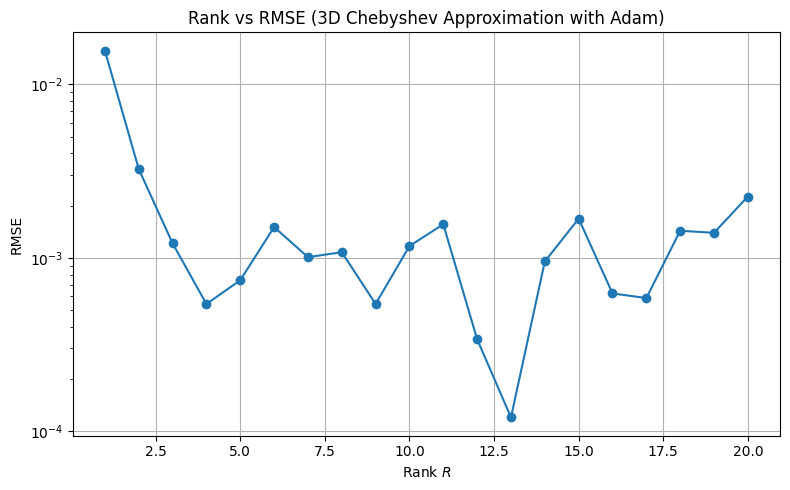

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander
from autograd import grad
import autograd.numpy as anp

# 3D function to approximate
def f(x, y, z, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2 + z**2))

# Settings
N = M = L = 64
d_x = d_y = d_z = 63
lr = 1e-2
num_iters = 300

# Chebyshev nodes
x_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
y_nodes = np.cos(np.pi * np.arange(M) / (M - 1))
z_nodes = np.cos(np.pi * np.arange(L) / (L - 1))

X, Y, Z = np.meshgrid(x_nodes, y_nodes, z_nodes, indexing='ij')
F = f(X, Y, Z)
F_autograd = anp.array(F)

# Chebyshev basis evaluations
Tx = chebvander(x_nodes, d_x)
Ty = chebvander(y_nodes, d_y)
Tz = chebvander(z_nodes, d_z)
Tx_a = anp.array(Tx)
Ty_a = anp.array(Ty)
Tz_a = anp.array(Tz)

# Packing/unpacking
def pack_params(A, B, C, lambdas):
    return anp.concatenate([A.ravel(), B.ravel(), C.ravel(), lambdas])

def unpack_params(params, R):
    A_size = (d_x + 1) * R
    B_size = (d_y + 1) * R
    C_size = (d_z + 1) * R
    A = params[:A_size].reshape((d_x + 1, R))
    B = params[A_size:A_size+B_size].reshape((d_y + 1, R))
    C = params[A_size+B_size:A_size+B_size+C_size].reshape((d_z + 1, R))
    lambdas = params[-R:]
    return A, B, C, lambdas

# Loss function
def loss_fn(params, R):
    A, B, C, lambdas = unpack_params(params, R)
    A_eval = Tx_a @ A       # (N, R)
    B_eval = Ty_a @ B       # (M, R)
    C_eval = Tz_a @ C       # (L, R)
    F_hat = anp.zeros_like(F_autograd)
    for r in range(R):
        F_hat += lambdas[r] * anp.einsum('i,j,k->ijk', A_eval[:, r], B_eval[:, r], C_eval[:, r])
    return anp.mean((F_autograd - F_hat)**2)

# Adam update
def adam_update(params, grads, m, v, t, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
    m = beta1 * m + (1 - beta1) * grads
    v = beta2 * v + (1 - beta2) * (grads ** 2)
    m_hat = m / (1 - beta1 ** t)
    v_hat = v / (1 - beta2 ** t)
    params -= lr * m_hat / (anp.sqrt(v_hat) + eps)
    return params, m, v

# Loop over ranks
ranks = range(1, 21)
rmses = []

for R in ranks:
    print(f"\nRank R = {R}")
    np.random.seed(42)
    A_init = 0.01 * np.random.randn(d_x + 1, R)
    B_init = 0.01 * np.random.randn(d_y + 1, R)
    C_init = 0.01 * np.random.randn(d_z + 1, R)
    lambdas_init = np.ones(R)
    params = pack_params(A_init, B_init, C_init, lambdas_init)

    m = anp.zeros_like(params)
    v = anp.zeros_like(params)
    grad_loss = grad(lambda p: loss_fn(p, R))

    for t in range(1, num_iters + 1):
        grads = grad_loss(params)
        params, m, v = adam_update(params, grads, m, v, t, lr=lr)

    A_opt, B_opt, C_opt, lambdas_opt = unpack_params(params, R)
    A_eval = Tx @ A_opt
    B_eval = Ty @ B_opt
    C_eval = Tz @ C_opt
    F_hat = np.zeros_like(F)
    for r in range(R):
        F_hat += lambdas_opt[r] * np.einsum('i,j,k->ijk', A_eval[:, r], B_eval[:, r], C_eval[:, r])
    rmse = np.sqrt(np.mean((F - F_hat)**2))
    print(f"Final RMSE for R={R}: {rmse:.4e}")
    rmses.append(rmse)

# Plot Rank vs RMSE
plt.figure(figsize=(8, 5))
plt.plot(ranks, rmses, marker='o')
plt.xscale('linear')
plt.yscale('log')
plt.xlabel('Rank $R$')
plt.ylabel('RMSE')
plt.title('Rank vs RMSE (3D Chebyshev Approximation with Adam)')
plt.grid(True)
plt.tight_layout()
plt.show()


<>:111: SyntaxWarning: invalid escape sequence '\h'
<>:111: SyntaxWarning: invalid escape sequence '\h'
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2109322162.py:111: SyntaxWarning: invalid escape sequence '\h'
  axs[1].set_title("Approximated $\hat{f}(x, y, z=0, w=0)$")
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2109322162.py:47: RuntimeWarning: divide by zero encountered in matmul
  Ax = Tx @ A
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2109322162.py:47: RuntimeWarning: overflow encountered in matmul
  Ax = Tx @ A
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2109322162.py:47: RuntimeWarning: invalid value encountered in matmul
  Ax = Tx @ A
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2109322162.py:48: RuntimeWarning: divide by zero encountered in matmul
  By = Ty @ B
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2109322162.py:48: RuntimeWarning: overflow encoun

Iter    1, Loss = 8.1195e-04
Iter   50, Loss = 3.4950e-05
Iter  100, Loss = 1.9308e-06
Iter  150, Loss = 8.5772e-07
Iter  200, Loss = 4.9214e-07
Iter  250, Loss = 3.1018e-07
Iter  300, Loss = 3.0197e-07
Iter  350, Loss = 1.8154e-07
Iter  400, Loss = 1.5725e-07
Iter  450, Loss = 3.1432e-07
Iter  500, Loss = 1.0817e-07
Final RMSE: 3.29e-04


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2109322162.py:89: RuntimeWarning: divide by zero encountered in matmul
  Ax = T @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2109322162.py:89: RuntimeWarning: overflow encountered in matmul
  Ax = T @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2109322162.py:89: RuntimeWarning: invalid value encountered in matmul
  Ax = T @ A_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2109322162.py:90: RuntimeWarning: divide by zero encountered in matmul
  By = T @ B_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2109322162.py:90: RuntimeWarning: overflow encountered in matmul
  By = T @ B_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2109322162.py:90: RuntimeWarning: invalid value encountered in matmul
  By = T @ B_opt
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2109322162.py:91: RuntimeWarnin

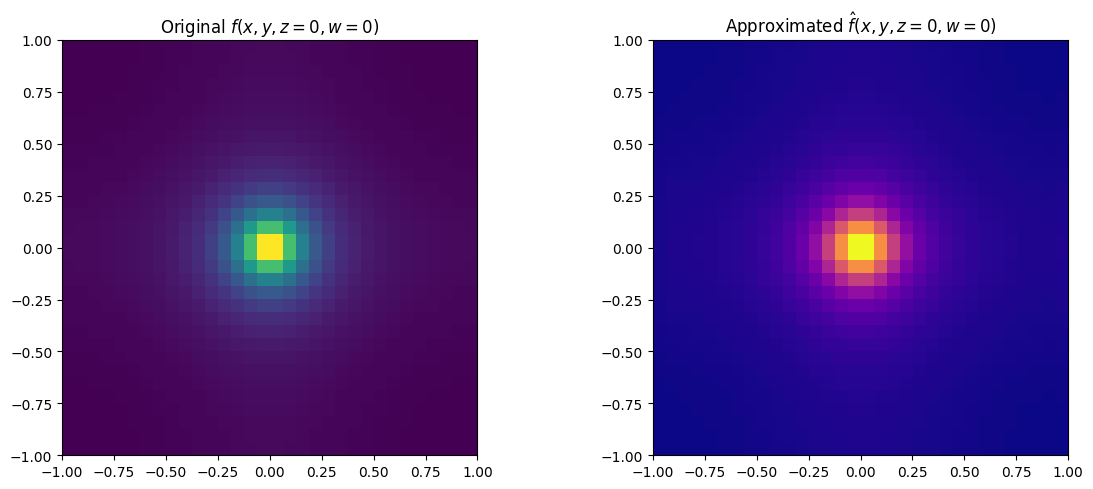

In [ ]:
# Adam optimization (with autograd) in 4D with 32x32x32x32 grid

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander
from autograd import grad
import autograd.numpy as anp

# Target function to approximate (4D)
def f(x, y, z, w, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2 + z**2 + w**2))

# Settings
N = 32        # grid size per dimension
d = N - 1     # Chebyshev degree
R = 10        # rank
lr = 1e-2
num_iters = 500

# Chebyshev nodes
nodes = np.cos(np.pi * np.arange(N) / (N - 1))
X, Y, Z, W = np.meshgrid(nodes, nodes, nodes, nodes, indexing='ij')
F = f(X, Y, Z, W)
F_autograd = anp.array(F)

# Chebyshev basis matrices
T = chebvander(nodes, d)
Tx = anp.array(T)
Ty = anp.array(T)
Tz = anp.array(T)
Tw = anp.array(T)

# Param pack/unpack
def pack_params(A, B, C, D, lambdas):
    return anp.concatenate([A.ravel(), B.ravel(), C.ravel(), D.ravel(), lambdas])

def unpack_params(params):
    size = (d+1) * R
    A = params[:size].reshape((d+1, R))
    B = params[size:2*size].reshape((d+1, R))
    C = params[2*size:3*size].reshape((d+1, R))
    D = params[3*size:4*size].reshape((d+1, R))
    lambdas = params[4*size:]
    return A, B, C, D, lambdas

# Loss function
def loss(params):
    A, B, C, D, lambdas = unpack_params(params)
    Ax = Tx @ A
    By = Ty @ B
    Cz = Tz @ C
    Dw = Tw @ D
    F_hat = anp.zeros((N, N, N, N))
    for r in range(R):
        F_hat += lambdas[r] * anp.einsum('i,j,k,l->ijkl', Ax[:, r], By[:, r], Cz[:, r], Dw[:, r])
    return anp.mean((F_autograd - F_hat)**2)

# Adam update
def adam_update(params, grads, m, v, t, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
    m = beta1 * m + (1 - beta1) * grads
    v = beta2 * v + (1 - beta2) * (grads ** 2)
    m_hat = m / (1 - beta1 ** t)
    v_hat = v / (1 - beta2 ** t)
    params -= lr * m_hat / (anp.sqrt(v_hat) + eps)
    return params, m, v

# Initialization
np.random.seed(42)
A_init = 0.01 * np.random.randn(d+1, R)
B_init = 0.01 * np.random.randn(d+1, R)
C_init = 0.01 * np.random.randn(d+1, R)
D_init = 0.01 * np.random.randn(d+1, R)
lambdas_init = np.ones(R)
params = pack_params(A_init, B_init, C_init, D_init, lambdas_init)

# Adam state
m = anp.zeros_like(params)
v = anp.zeros_like(params)

# Train loop
grad_loss = grad(loss)
for t in range(1, num_iters + 1):
    grads = grad_loss(params)
    params, m, v = adam_update(params, grads, m, v, t, lr=lr)
    if t % 50 == 0 or t == 1:
        l = loss(params)
        print(f"Iter {t:4d}, Loss = {l:.4e}")

# Final reconstruction
A_opt, B_opt, C_opt, D_opt, lambdas_opt = unpack_params(params)
Ax = T @ A_opt
By = T @ B_opt
Cz = T @ C_opt
Dw = T @ D_opt
F_hat = np.zeros((N, N, N, N))
for r in range(R):
    F_hat += lambdas_opt[r] * np.einsum('i,j,k,l->ijkl', Ax[:, r], By[:, r], Cz[:, r], Dw[:, r])
rmse = np.sqrt(np.mean((F - F_hat)**2))
print(f"Final RMSE: {rmse:.2e}")

# Visualization: slice at w = 0
w_index = N // 2
slice_F = F[:, :, :, w_index]
slice_Fhat = F_hat[:, :, :, w_index]

# Visualize 3D slice (z=0)
z_index = N // 2
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(slice_F[:, :, z_index], extent=[-1, 1, -1, 1], origin='lower', cmap='viridis')
axs[0].set_title("Original $f(x, y, z=0, w=0)$")

axs[1].imshow(slice_Fhat[:, :, z_index], extent=[-1, 1, -1, 1], origin='lower', cmap='plasma')
axs[1].set_title("Approximated $\hat{f}(x, y, z=0, w=0)$")

plt.tight_layout()
plt.show()


In [ ]:
# SELF IMPLEMENTED SGD in 2D with Chebyshev basis (DISCARDED)


import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander

# Function to approximate
def f(x, y, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2))

# Settings
N, M = 64, 64               # number of Chebyshev nodes
d_x, d_y = 63, 63           # polynomial degrees
R = 10                    # CP rank
n_iter = 5000             # SGD iterations
lr = 1e-3                 # learning rate
epsilon = 1e-8            # small value to avoid div by zero
grad_clip = 1.0           # max gradient norm

# Chebyshev nodes
x_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
y_nodes = np.cos(np.pi * np.arange(M) / (M - 1))
X, Y = np.meshgrid(x_nodes, y_nodes, indexing='ij')
F = f(X, Y)

# Chebyshev basis matrices
Tx = chebvander(x_nodes, d_x)
Ty = chebvander(y_nodes, d_y)

# Normalize basis rows to reduce scale variance
Tx /= np.linalg.norm(Tx, axis=1, keepdims=True)
Ty /= np.linalg.norm(Ty, axis=1, keepdims=True)

# Initialize parameters with small values
A_coeffs = 0.01 * np.random.randn(d_x + 1, R)
B_coeffs = 0.01 * np.random.randn(d_y + 1, R)
lambdas = np.ones(R)

# Gradient clipping function
def clip_gradients(grad, max_norm=1.0):
    norm = np.linalg.norm(grad)
    if norm > max_norm:
        return grad * (max_norm / (norm + epsilon))
    return grad

# SGD loop
for it in range(n_iter):
    # Random sample (i, j)
    i = np.random.randint(N)
    j = np.random.randint(M)

    Tx_i = Tx[i]  # (d_x+1,)
    Ty_j = Ty[j]  # (d_y+1,)

    # Predicted value at (i, j)
    approx = sum(
        lambdas[r] * (Tx_i @ A_coeffs[:, r]) * (Ty_j @ B_coeffs[:, r])
        for r in range(R)
    )
    target = F[i, j]
    err = approx - target

    # SGD updates for each component
    for r in range(R):
        a_r = Tx_i @ A_coeffs[:, r]
        b_r = Ty_j @ B_coeffs[:, r]

        grad_A = err * lambdas[r] * b_r * Tx_i
        grad_B = err * lambdas[r] * a_r * Ty_j
        grad_lambda = err * a_r * b_r

        A_coeffs[:, r] -= lr * clip_gradients(grad_A, grad_clip)
        B_coeffs[:, r] -= lr * clip_gradients(grad_B, grad_clip)
        lambdas[r] -= lr * np.clip(grad_lambda, -10, 10)  # scalar clip

    # Optional clipping to keep values in a reasonable range
    lambdas = np.clip(lambdas, 1e-3, 1e3)

    # Monitor RMSE every few iterations
    if it % 500 == 0:
        A_eval = Tx @ A_coeffs
        B_eval = Ty @ B_coeffs
        F_hat = sum(lambdas[r] * np.outer(A_eval[:, r], B_eval[:, r]) for r in range(R))
        rmse = np.sqrt(np.mean((F - F_hat)**2))
        print(f"Iter {it}, RMSE: {rmse:.2e}")


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2376644741.py:79: RuntimeWarning: divide by zero encountered in matmul
  A_eval = Tx @ A_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2376644741.py:79: RuntimeWarning: overflow encountered in matmul
  A_eval = Tx @ A_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2376644741.py:79: RuntimeWarning: invalid value encountered in matmul
  A_eval = Tx @ A_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2376644741.py:80: RuntimeWarning: divide by zero encountered in matmul
  B_eval = Ty @ B_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2376644741.py:80: RuntimeWarning: overflow encountered in matmul
  B_eval = Ty @ B_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_66904/2376644741.py:80: RuntimeWarning: invalid value encountered in matmul
  B_eval = Ty @ B_coeffs


Iter 0, RMSE: 1.15e-01
Iter 500, RMSE: 1.15e-01
Iter 1000, RMSE: 1.15e-01
Iter 1500, RMSE: 1.15e-01
Iter 2000, RMSE: 1.15e-01
Iter 2500, RMSE: 1.15e-01
Iter 3000, RMSE: 1.15e-01
Iter 3500, RMSE: 1.15e-01
Iter 4000, RMSE: 1.15e-01
Iter 4500, RMSE: 1.15e-01


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander

# Function to approximate
def f(x, y, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2))

# Settings
N, M = 8, 8               # number of Chebyshev nodes
d_x, d_y = 7, 7           # polynomial degrees
R = 10                    # CP rank
n_iter = 1000             # SGD iterations
lr = 1e-3                 # learning rate
epsilon = 1e-8            # small value to avoid div by zero
grad_clip = 1.0           # max gradient norm
reg = 1e-3                # L2 regularization strength

# Chebyshev nodes
x_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
y_nodes = np.cos(np.pi * np.arange(M) / (M - 1))
X, Y = np.meshgrid(x_nodes, y_nodes, indexing='ij')
F = f(X, Y)

# Chebyshev basis matrices
Tx = chebvander(x_nodes, d_x)
Ty = chebvander(y_nodes, d_y)

# Normalize basis rows
Tx /= np.linalg.norm(Tx, axis=1, keepdims=True)
Ty /= np.linalg.norm(Ty, axis=1, keepdims=True)

# Initialize parameters
A_coeffs = 0.01 * np.random.randn(d_x + 1, R)
B_coeffs = 0.01 * np.random.randn(d_y + 1, R)
lambdas = np.ones(R)

# Gradient clipping function
def clip_gradients(grad, max_norm=1.0):
    norm = np.linalg.norm(grad)
    if norm > max_norm:
        return grad * (max_norm / (norm + epsilon))
    return grad

# SGD loop
for it in range(n_iter):
    i = np.random.randint(N)
    j = np.random.randint(M)

    Tx_i = Tx[i]  # (d_x+1,)
    Ty_j = Ty[j]  # (d_y+1,)

    approx = sum(
        lambdas[r] * (Tx_i @ A_coeffs[:, r]) * (Ty_j @ B_coeffs[:, r])
        for r in range(R)
    )
    target = F[i, j]
    err = approx - target

    for r in range(R):
        a_r = Tx_i @ A_coeffs[:, r]
        b_r = Ty_j @ B_coeffs[:, r]

        # Compute gradients + L2 regularization
        grad_A = err * lambdas[r] * b_r * Tx_i + reg * A_coeffs[:, r]
        grad_B = err * lambdas[r] * a_r * Ty_j + reg * B_coeffs[:, r]
        grad_lambda = err * a_r * b_r + reg * lambdas[r]

        A_coeffs[:, r] -= lr * clip_gradients(grad_A, grad_clip)
        B_coeffs[:, r] -= lr * clip_gradients(grad_B, grad_clip)
        lambdas[r] -= lr * np.clip(grad_lambda, -10, 10)

    lambdas = np.clip(lambdas, 1e-3, 1e3)

    if True:
        A_eval = Tx @ A_coeffs
        B_eval = Ty @ B_coeffs
        F_hat = sum(lambdas[r] * np.outer(A_eval[:, r], B_eval[:, r]) for r in range(R))
        rmse = np.sqrt(np.mean((F - F_hat)**2))
        print(f"Iter {it}, RMSE: {rmse:.2e}")


Iter 0, RMSE: 8.33e-02
Iter 1, RMSE: 8.33e-02
Iter 2, RMSE: 8.33e-02
Iter 3, RMSE: 8.33e-02
Iter 4, RMSE: 8.33e-02
Iter 5, RMSE: 8.33e-02
Iter 6, RMSE: 8.33e-02
Iter 7, RMSE: 8.33e-02
Iter 8, RMSE: 8.33e-02
Iter 9, RMSE: 8.33e-02
Iter 10, RMSE: 8.33e-02
Iter 11, RMSE: 8.33e-02
Iter 12, RMSE: 8.33e-02
Iter 13, RMSE: 8.33e-02
Iter 14, RMSE: 8.33e-02
Iter 15, RMSE: 8.33e-02
Iter 16, RMSE: 8.33e-02
Iter 17, RMSE: 8.33e-02
Iter 18, RMSE: 8.33e-02
Iter 19, RMSE: 8.33e-02
Iter 20, RMSE: 8.33e-02
Iter 21, RMSE: 8.33e-02
Iter 22, RMSE: 8.33e-02
Iter 23, RMSE: 8.33e-02
Iter 24, RMSE: 8.33e-02
Iter 25, RMSE: 8.33e-02
Iter 26, RMSE: 8.33e-02
Iter 27, RMSE: 8.33e-02
Iter 28, RMSE: 8.33e-02
Iter 29, RMSE: 8.33e-02
Iter 30, RMSE: 8.33e-02
Iter 31, RMSE: 8.33e-02
Iter 32, RMSE: 8.33e-02
Iter 33, RMSE: 8.33e-02
Iter 34, RMSE: 8.33e-02
Iter 35, RMSE: 8.33e-02
Iter 36, RMSE: 8.33e-02
Iter 37, RMSE: 8.33e-02
Iter 38, RMSE: 8.33e-02
Iter 39, RMSE: 8.33e-02
Iter 40, RMSE: 8.33e-02
Iter 41, RMSE: 8.33e-02
It

/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_45894/647538896.py:76: RuntimeWarning: divide by zero encountered in matmul
  A_eval = Tx @ A_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_45894/647538896.py:76: RuntimeWarning: overflow encountered in matmul
  A_eval = Tx @ A_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_45894/647538896.py:76: RuntimeWarning: invalid value encountered in matmul
  A_eval = Tx @ A_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_45894/647538896.py:77: RuntimeWarning: divide by zero encountered in matmul
  B_eval = Ty @ B_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_45894/647538896.py:77: RuntimeWarning: overflow encountered in matmul
  B_eval = Ty @ B_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_45894/647538896.py:77: RuntimeWarning: invalid value encountered in matmul
  B_eval = Ty @ B_coeffs


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander

# Function to approximate
def f(x, y, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2))

# Settings
N, M = 8, 8               # number of Chebyshev nodes
d_x, d_y = 7, 7           # polynomial degrees
R = 10                    # CP rank
n_iter = 1000             # SGD iterations
lr = 1e-3                 # learning rate
reg = 1e-2                # L2 regularization strength
epsilon = 1e-8            # for numerical stability

# Chebyshev nodes
x_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
y_nodes = np.cos(np.pi * np.arange(M) / (M - 1))
X, Y = np.meshgrid(x_nodes, y_nodes, indexing='ij')
F = f(X, Y)

# Chebyshev basis matrices
Tx = chebvander(x_nodes, d_x)
Ty = chebvander(y_nodes, d_y)

# Normalize basis rows
Tx /= np.linalg.norm(Tx, axis=1, keepdims=True)
Ty /= np.linalg.norm(Ty, axis=1, keepdims=True)

# Initialize parameters
A_coeffs = 0.01 * np.random.randn(d_x + 1, R)
B_coeffs = 0.01 * np.random.randn(d_y + 1, R)
lambdas = np.ones(R)

# SGD loop
for it in range(n_iter):
    # Random sample (i, j)
    i = np.random.randint(N)
    j = np.random.randint(M)

    Tx_i = Tx[i]  # (d_x+1,)
    Ty_j = Ty[j]  # (d_y+1,)

    # Predicted value at (i, j)
    approx = sum(
        lambdas[r] * (Tx_i @ A_coeffs[:, r]) * (Ty_j @ B_coeffs[:, r])
        for r in range(R)
    )
    target = F[i, j]
    err = approx - target

    # SGD updates with L2 regularization (no clipping)
    for r in range(R):
        a_r = Tx_i @ A_coeffs[:, r]
        b_r = Ty_j @ B_coeffs[:, r]

        grad_A = err * lambdas[r] * b_r * Tx_i + reg * A_coeffs[:, r]
        grad_B = err * lambdas[r] * a_r * Ty_j + reg * B_coeffs[:, r]
        grad_lambda = err * a_r * b_r + reg * lambdas[r]

        A_coeffs[:, r] -= lr * grad_A
        B_coeffs[:, r] -= lr * grad_B
        lambdas[r] -= lr * grad_lambda

    # Optional: prevent runaway growth
    lambdas = np.clip(lambdas, 1e-3, 1e3)

    # Log RMSE every 500 iterations
    if True:
        A_eval = Tx @ A_coeffs
        B_eval = Ty @ B_coeffs
        F_hat = sum(lambdas[r] * np.outer(A_eval[:, r], B_eval[:, r]) for r in range(R))
        rmse = np.sqrt(np.mean((F - F_hat)**2))
        print(f"Iter {it}, RMSE: {rmse:.2e}")


Iter 0, RMSE: 8.34e-02
Iter 1, RMSE: 8.34e-02
Iter 2, RMSE: 8.34e-02
Iter 3, RMSE: 8.34e-02
Iter 4, RMSE: 8.34e-02
Iter 5, RMSE: 8.34e-02
Iter 6, RMSE: 8.34e-02
Iter 7, RMSE: 8.34e-02
Iter 8, RMSE: 8.34e-02
Iter 9, RMSE: 8.34e-02
Iter 10, RMSE: 8.34e-02
Iter 11, RMSE: 8.34e-02
Iter 12, RMSE: 8.34e-02
Iter 13, RMSE: 8.34e-02
Iter 14, RMSE: 8.34e-02
Iter 15, RMSE: 8.34e-02
Iter 16, RMSE: 8.34e-02
Iter 17, RMSE: 8.34e-02
Iter 18, RMSE: 8.34e-02
Iter 19, RMSE: 8.34e-02
Iter 20, RMSE: 8.34e-02
Iter 21, RMSE: 8.34e-02
Iter 22, RMSE: 8.34e-02
Iter 23, RMSE: 8.34e-02
Iter 24, RMSE: 8.34e-02
Iter 25, RMSE: 8.34e-02
Iter 26, RMSE: 8.34e-02
Iter 27, RMSE: 8.34e-02
Iter 28, RMSE: 8.34e-02
Iter 29, RMSE: 8.34e-02
Iter 30, RMSE: 8.34e-02
Iter 31, RMSE: 8.34e-02
Iter 32, RMSE: 8.34e-02
Iter 33, RMSE: 8.34e-02
Iter 34, RMSE: 8.34e-02
Iter 35, RMSE: 8.34e-02
Iter 36, RMSE: 8.34e-02
Iter 37, RMSE: 8.34e-02
Iter 38, RMSE: 8.34e-02
Iter 39, RMSE: 8.34e-02
Iter 40, RMSE: 8.34e-02
Iter 41, RMSE: 8.34e-02
It

/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_45894/2367933663.py:72: RuntimeWarning: divide by zero encountered in matmul
  A_eval = Tx @ A_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_45894/2367933663.py:72: RuntimeWarning: overflow encountered in matmul
  A_eval = Tx @ A_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_45894/2367933663.py:72: RuntimeWarning: invalid value encountered in matmul
  A_eval = Tx @ A_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_45894/2367933663.py:73: RuntimeWarning: divide by zero encountered in matmul
  B_eval = Ty @ B_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_45894/2367933663.py:73: RuntimeWarning: overflow encountered in matmul
  B_eval = Ty @ B_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_45894/2367933663.py:73: RuntimeWarning: invalid value encountered in matmul
  B_eval = Ty @ B_coeffs


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander

# Function to approximate
def f(x, y, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2))

# Settings
N, M = 8, 8
d_x, d_y = 7, 7
R = 10
n_iter = 10000
lr = 5e-3
reg = 1e-10
beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8

# Chebyshev nodes and basis
x_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
y_nodes = np.cos(np.pi * np.arange(M) / (M - 1))
X, Y = np.meshgrid(x_nodes, y_nodes, indexing='ij')
F = f(X, Y)

Tx = chebvander(x_nodes, d_x)
Ty = chebvander(y_nodes, d_y)
Tx /= np.linalg.norm(Tx, axis=1, keepdims=True)
Ty /= np.linalg.norm(Ty, axis=1, keepdims=True)

# Initialize parameters
A = 0.01 * np.random.randn(d_x + 1, R)
B = 0.01 * np.random.randn(d_y + 1, R)
lambdas = np.ones(R)

# Initialize Adam moment estimates
m_A = np.zeros_like(A)
v_A = np.zeros_like(A)
m_B = np.zeros_like(B)
v_B = np.zeros_like(B)
m_l = np.zeros_like(lambdas)
v_l = np.zeros_like(lambdas)

# SGD loop with Adam
for t in range(1, n_iter + 1):
    i = np.random.randint(N)
    j = np.random.randint(M)
    Tx_i = Tx[i]
    Ty_j = Ty[j]

    approx = sum(lambdas[r] * (Tx_i @ A[:, r]) * (Ty_j @ B[:, r]) for r in range(R))
    target = F[i, j]
    err = approx - target

    for r in range(R):
        a_r = Tx_i @ A[:, r]
        b_r = Ty_j @ B[:, r]

        grad_A = err * lambdas[r] * b_r * Tx_i + reg * A[:, r]
        grad_B = err * lambdas[r] * a_r * Ty_j + reg * B[:, r]
        grad_lambda = err * a_r * b_r + reg * lambdas[r]

        # Update moments for A
        m_A[:, r] = beta1 * m_A[:, r] + (1 - beta1) * grad_A
        v_A[:, r] = beta2 * v_A[:, r] + (1 - beta2) * (grad_A**2)
        m_A_hat = m_A[:, r] / (1 - beta1**t)
        v_A_hat = v_A[:, r] / (1 - beta2**t)
        A[:, r] -= lr * m_A_hat / (np.sqrt(v_A_hat) + epsilon)

        # Update moments for B
        m_B[:, r] = beta1 * m_B[:, r] + (1 - beta1) * grad_B
        v_B[:, r] = beta2 * v_B[:, r] + (1 - beta2) * (grad_B**2)
        m_B_hat = m_B[:, r] / (1 - beta1**t)
        v_B_hat = v_B[:, r] / (1 - beta2**t)
        B[:, r] -= lr * m_B_hat / (np.sqrt(v_B_hat) + epsilon)

        # Update moments for lambda
        m_l[r] = beta1 * m_l[r] + (1 - beta1) * grad_lambda
        v_l[r] = beta2 * v_l[r] + (1 - beta2) * (grad_lambda**2)
        m_l_hat = m_l[r] / (1 - beta1**t)
        v_l_hat = v_l[r] / (1 - beta2**t)
        lambdas[r] -= lr * m_l_hat / (np.sqrt(v_l_hat) + epsilon)

    # Optional: clamp lambda values to avoid divergence
    lambdas = np.clip(lambdas, 1e-3, 1e3)

    # RMSE logging
    if True:
        A_eval = Tx @ A
        B_eval = Ty @ B
        F_hat = sum(lambdas[r] * np.outer(A_eval[:, r], B_eval[:, r]) for r in range(R))
        rmse = np.sqrt(np.mean((F - F_hat)**2))
        print(f"Iter {t}, RMSE: {rmse:.2e}")


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_45894/4245575915.py:89: RuntimeWarning: divide by zero encountered in matmul
  A_eval = Tx @ A
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_45894/4245575915.py:89: RuntimeWarning: overflow encountered in matmul
  A_eval = Tx @ A
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_45894/4245575915.py:89: RuntimeWarning: invalid value encountered in matmul
  A_eval = Tx @ A
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_45894/4245575915.py:90: RuntimeWarning: divide by zero encountered in matmul
  B_eval = Ty @ B
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_45894/4245575915.py:90: RuntimeWarning: overflow encountered in matmul
  B_eval = Ty @ B
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_45894/4245575915.py:90: RuntimeWarning: invalid value encountered in matmul
  B_eval = Ty @ B


Iter 1, RMSE: 8.34e-02
Iter 2, RMSE: 8.34e-02
Iter 3, RMSE: 8.33e-02
Iter 4, RMSE: 8.32e-02
Iter 5, RMSE: 8.31e-02
Iter 6, RMSE: 8.31e-02
Iter 7, RMSE: 8.30e-02
Iter 8, RMSE: 8.28e-02
Iter 9, RMSE: 8.27e-02
Iter 10, RMSE: 8.26e-02
Iter 11, RMSE: 8.24e-02
Iter 12, RMSE: 8.23e-02
Iter 13, RMSE: 8.21e-02
Iter 14, RMSE: 8.19e-02
Iter 15, RMSE: 8.17e-02
Iter 16, RMSE: 8.15e-02
Iter 17, RMSE: 8.12e-02
Iter 18, RMSE: 8.10e-02
Iter 19, RMSE: 8.07e-02
Iter 20, RMSE: 8.04e-02
Iter 21, RMSE: 8.02e-02
Iter 22, RMSE: 7.99e-02
Iter 23, RMSE: 7.94e-02
Iter 24, RMSE: 7.88e-02
Iter 25, RMSE: 7.83e-02
Iter 26, RMSE: 7.77e-02
Iter 27, RMSE: 7.71e-02
Iter 28, RMSE: 7.66e-02
Iter 29, RMSE: 7.61e-02
Iter 30, RMSE: 7.55e-02
Iter 31, RMSE: 7.50e-02
Iter 32, RMSE: 7.44e-02
Iter 33, RMSE: 7.39e-02
Iter 34, RMSE: 7.35e-02
Iter 35, RMSE: 7.31e-02
Iter 36, RMSE: 7.26e-02
Iter 37, RMSE: 7.22e-02
Iter 38, RMSE: 7.19e-02
Iter 39, RMSE: 7.15e-02
Iter 40, RMSE: 7.10e-02
Iter 41, RMSE: 7.05e-02
Iter 42, RMSE: 7.00e-02
I